# Energy Efficiency of Buildings: A Statistical Modelling Study

**Course:** DSA 8305 Linear Models
**Institution:** Strathmore Institute of Mathematical Sciences, Strathmore University
**Programme:** MSc Data Science and Analytics

| Student | Registration Number |
|:---|:---|
| Assumpta Mwikali | 134022 |
| Olive Mideva Muloma | 135792 |
| Trevor Anjeyo Vuhyah | 224038 |
| Valerie Jerono | 222331 |

---

## Abstract

This project applies the full spectrum of linear modelling techniques to the UCI ENB2012 dataset, which contains 768 simulated building configurations varying across eight architectural parameters. Beginning from Ordinary Least Squares as a parametric baseline, we progress through Ridge Regression, Principal Components Regression, Polynomial Regression, Regression Splines, Generalised Additive Models, Logistic Regression, and Decision Trees. Each model is motivated by a specific limitation identified in its predecessor. The analysis is structured within the CRISP-DM framework and yields actionable recommendations for energy-efficient building design at the concept stage. Key findings include the dominant influence of Overall Height on energy loads, severe geometric multicollinearity among compactness and area predictors, and a non-linear relationship between glazing area and heating demand. The best regression model achieves sub-1.0 kWh/m² RMSE on held-out test data, and the classification models demonstrate AUC exceeding 0.95 on a within-group formulation that controls for the confounding effect of building height.

---

## Study Overview

Buildings consume approximately 40% of global final energy. The decisions made at the architectural design stage, how compact the footprint is, how much glass to use, how tall to build, translate directly into decades of heating and cooling costs that are expensive to alter after construction. If those relationships can be modelled statistically, architects and engineers gain a quantitative lens at the earliest and cheapest point in the design process.

This notebook works through the full model progression of DSA 8305 applied to the UCI ENB2012 dataset.

| Model Class | Primary Contribution |
|:---|:---|
| OLS Multiple Regression | Parametric baseline; full inferential output via statsmodels |
| Ridge Regression | L2-regularised estimation; addresses severe multicollinearity |
| Principal Components Regression | Dimensionality reduction approach to collinear predictors |
| Polynomial Regression | Parametric non-linearity via basis expansion; bias-variance trade-off |
| Natural Cubic Splines | Piecewise polynomial smoothing; local flexibility with global continuity |
| Generalised Additive Models | Non-parametric smooth functions; semi-parametric partial-dependence inference |
| Logistic Regression | Binary classification via GLM; probabilistic building energy class assignment |
| Decision Tree | Non-parametric classification; explicit rule-based design guidance |

The analysis follows the **CRISP-DM** framework, the industry-standard iterative process comprising six phases: Business Understanding, Data Understanding, Data Preparation, Modelling, Evaluation, and Deployment. Each phase informs the next, and findings in one phase are explicitly linked to decisions in subsequent phases.

**Table of Contents**

| Phase | Section |
|:---|:---|
| 1 | Business Understanding |
| 2 | Data Understanding and EDA |
| 3 | Data Preparation and Feature Engineering |
| 4 | Modelling: OLS, Ridge, PCR, Polynomial, Splines, GAM, Classification |
| 5 | Evaluation and Model Comparison |
| 6 | Conclusions and Deployment Implications |


# Phase 1: Business Understanding

## 1.1 The Energy Performance Problem

The built environment is the single largest consumer of final energy globally. The IEA estimates that buildings account for approximately 40% of global final energy consumption and 36% of energy-related CO2 emissions, a share that exceeds both transport and industry. In the African context, rapid urbanisation and a construction boom across East Africa's major cities make this problem acutely relevant: the design decisions being made today will shape energy demand for the next 50 to 100 years.

The central insight motivating this study is that the majority of a building's energy cost is determined before construction begins. Geometric parameters, how compact the footprint is, how much of the envelope is glazed, how tall the structure is, are fixed at the concept design stage. Statistical models that accurately predict energy performance from architectural geometry provide an inexpensive, high-leverage intervention in the design process.

## 1.2 Research Questions

This study addresses three nested questions, progressing from broad to precise.

**Question 1: Primary Regression.** Given a building's geometric and architectural characteristics, what will its annual heating load and cooling load be, measured in kWh/m²? Accurate regression enables quantity surveyors to size HVAC systems correctly from the outset.

**Question 2: Classification.** Can buildings be reliably categorised as high-efficiency or low-efficiency before construction, based solely on architectural design parameters? Even a coarse classification supports go/no-go decisions at concept stage, saving the cost of detailed energy simulation for designs that are clearly inefficient.

**Question 3: Diagnostic.** Which architectural features most strongly drive energy loads? Is the relationship linear or non-linear? Do features interact? Answering this question moves the analysis from predictive to explanatory, providing the physical intuition that architects need to act on model guidance.

## 1.3 The ENB2012 Dataset

The ENB2012 dataset (Tsanas and Xifara, 2012) was generated using Ecotect, a validated building energy simulation tool. Eight architectural parameters were systematically varied across 768 building configurations, producing a balanced and complete dataset. Both response variables, Heating Load (Y1) and Cooling Load (Y2), represent annual energy demand per unit floor area under standardised climate conditions.

| Variable | Label | Description | Scale |
|:---|:---|:---|:---|
| X1 | Relative Compactness | Volume-to-surface-area ratio | Continuous [0.62, 0.98] |
| X2 | Surface Area | Total external envelope area (m²) | Continuous [514, 808] |
| X3 | Wall Area | Total wall area (m²) | Continuous [245, 416] |
| X4 | Roof Area | Roof footprint area (m²) | Continuous [110, 221] |
| X5 | Overall Height | Building height (m) | Effectively binary: 3.5 or 7.0 |
| X6 | Orientation | Cardinal direction of primary facade | Nominal: N=2, E=3, S=4, W=5 |
| X7 | Glazing Area | Glazed proportion of floor area | Discrete: 0, 0.10, 0.25, 0.40 |
| X8 | Glazing Area Distribution | Allocation of glazing across facades | Ordinal: 0 to 5 |
| Y1 | Heating Load | Annual heating energy demand (kWh/m²) | Continuous response |
| Y2 | Cooling Load | Annual cooling energy demand (kWh/m²) | Continuous response |

Two variables require special attention before any model is fitted. X5 (Overall Height) takes only two values across all 768 observations: 3.5 m and 7.0 m. It is functionally binary, creating two structurally different building populations with different thermal envelopes. X6 (Orientation) uses codes 2, 3, 4, 5 to represent North, East, South, West. These are nominal labels with no arithmetic ordering. Treating them as continuous would impose a false relationship and produce physically meaningless coefficients.

## 1.4 What Constitutes a Good Result?

For regression, RMSE below 2.0 kWh/m² would be considered excellent, representing less than 5% of the typical load range. R² above 0.95 would indicate the model captures the dominant sources of variation. For classification, AUC above 0.90 indicates excellent discriminative ability, and accuracy above 80% on the within-group formulation would constitute strong performance. For interpretability, coefficient signs should be consistent with building physics theory, and partial dependence plots should confirm or challenge theoretical expectations.


# Environment Setup

Before any analysis begins, we assemble our tools. The libraries below represent four distinct traditions:

- **Classical statistics:** `numpy`, `scipy`, `statsmodels`
- **Machine learning:** `scikit-learn`
- **Flexible non-parametric modelling:** `pygam`, `patsy`
- **Visualisation:** `matplotlib`, `seaborn`

A few choices here deserve brief explanation. We use `statsmodels` rather than scikit-learn's `LinearRegression` throughout the regression sections because `statsmodels` exposes the full inferential apparatus: coefficient standard errors, t-statistics, p-values, confidence intervals, the overall F-test, and residual diagnostics. These are not optional extras; they are the reason we fit linear models rather than just predicting with black-box methods.

`patsy` handles natural cubic spline basis construction, and `pygam` fits Generalised Additive Models with automatic smoothness selection. Both are checked at import and the analysis degrades gracefully if either is unavailable.

A global random seed of 42 is set for reproducibility of all stochastic procedures: train-test splits, cross-validation fold assignment, and permutation importance.


In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})
sns.set_palette('husl')
BLUE, ORANGE, GREEN, RED, PURPLE = '#2196F3', '#FF5722', '#4CAF50', '#E91E63', '#9C27B0'

# ── Statistical Modelling ─────────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression, Lasso, LassoCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance

# ── Splines ───────────────────────────────────────────────────────────────────
try:
    from patsy import dmatrix
    PATSY_AVAILABLE = True
except ImportError:
    PATSY_AVAILABLE = False
    print("patsy not found — install with: pip install patsy")

# ── GAM ───────────────────────────────────────────────────────────────────────
try:
    from pygam import LinearGAM, s, f, l
    GAM_AVAILABLE = True
    print("pygam loaded successfully")
except ImportError:
    GAM_AVAILABLE = False
    print("pygam not found — install with: pip install pygam")

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import shapiro, boxcox

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print("All libraries loaded successfully.")
print(f"Global random seed: {RANDOM_STATE}")


pygam loaded successfully
pandas 2.3.0 | numpy 2.1.3
All libraries loaded successfully.
Global random seed: 42


# Phase 2: Data Understanding

## 2.1 Loading and First Inspection

Exploratory Data Analysis is not a preliminary formality. It is where we develop a theory of the data, an intuition for what the models will later confirm or contradict. George Box's maxim that all models are wrong, but some are useful, only holds if we first understand the data well enough to know which wrongness matters.

The first inspection has three objectives. First, a structural audit to confirm dimensions, types, and absence of data quality issues. Second, a unique value mapping to identify quasi-categorical continuous variables (X5, X6) that require special treatment. Third, a distributional characterisation to understand the spread, skewness, and potential outliers in both features and responses.

Every modelling decision in Phase 4 will be grounded in specific findings from this phase.


In [2]:
# Load dataset and assign descriptive column names
energy_data = pd.read_excel('ENB2012_data 2.xlsx')

energy_data.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'
]

print(f"Dataset dimensions: {energy_data.shape[0]} observations × {energy_data.shape[1]} variables")
print(f"\nColumn data types:")
print(energy_data.dtypes.to_string())
print(f"\nFirst five observations:")
display(energy_data.head())


Dataset dimensions: 768 observations × 10 variables

Column data types:
Relative_Compactness         float64
Surface_Area                 float64
Wall_Area                    float64
Roof_Area                    float64
Overall_Height               float64
Orientation                    int64
Glazing_Area                 float64
Glazing_Area_Distribution      int64
Heating_Load                 float64
Cooling_Load                 float64

First five observations:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
# ── Missing value audit ──────────────────────────────────────────────────────
missing = energy_data.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  None — dataset is complete.")

# ── Unique value mapping ──────────────────────────────────────────────────────
print("\nUnique value inventory (≤10 unique values shown explicitly):")
for col in energy_data.columns:
    uvals = sorted(energy_data[col].unique())
    if len(uvals) <= 10:
        print(f"  {col}: {uvals}")
    else:
        print(f"  {col}: {len(uvals)} unique values in "
              f"[{energy_data[col].min():.3f}, {energy_data[col].max():.3f}]")


Missing values per column:
  None — dataset is complete.

Unique value inventory (≤10 unique values shown explicitly):
  Relative_Compactness: 12 unique values in [0.620, 0.980]
  Surface_Area: 12 unique values in [514.500, 808.500]
  Wall_Area: [np.float64(245.0), np.float64(269.5), np.float64(294.0), np.float64(318.5), np.float64(343.0), np.float64(367.5), np.float64(416.5)]
  Roof_Area: [np.float64(110.25), np.float64(122.5), np.float64(147.0), np.float64(220.5)]
  Overall_Height: [np.float64(3.5), np.float64(7.0)]
  Orientation: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Glazing_Area: [np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.4)]
  Glazing_Area_Distribution: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Heating_Load: 587 unique values in [6.010, 43.100]
  Cooling_Load: 636 unique values in [10.900, 48.030]


### What the Initial Inspection Tells Us

The raw data reveal four structural facts that will shape every subsequent decision.

**Observation 1: X5 (Overall Height) is functionally binary.** Despite a numeric encoding, Overall Height takes only two values in the entire dataset: 3.5 m and 7.0 m, corresponding precisely to single-storey and double-storey building typologies. The consequences are significant. The dataset contains two structurally distinct building populations. Both response variables will display bimodal distributions, with two peaks corresponding to the two storey types. X5 will be the most powerful single predictor in every model, and any model that fails to capture the storey-height effect will systematically misclassify both populations.

**Observation 2: X6 (Orientation) is nominal categorical.** Orientation takes values 2, 3, 4, 5 as codes for North, East, South, West respectively. These integers carry no arithmetic meaning. Treating X6 as continuous would create a false ordinal relationship and produce physically meaningless coefficient estimates. One-hot encoding is mandatory.

**Observation 3: X7 (Glazing Area) takes only four discrete values.** Despite being conceptually continuous, the simulation used four levels: 0, 0.10, 0.25, and 0.40. Spline fits on X7 will be constrained to pass through these four mass-points, which limits the resolution of any detected non-linearity.

**Observation 4: No missing values.** The dataset is complete. No imputation is required.


In [4]:
# ── Extended descriptive statistics ──────────────────────────────────────────
desc = energy_data.describe().T
desc['CV_%']  = (desc['std'] / desc['mean'] * 100).round(1)   # coefficient of variation
desc['IQR']   = desc['75%'] - desc['25%']
desc['Skew']  = energy_data.skew().round(3)
desc['Kurt']  = energy_data.kurt().round(3)
desc['Range'] = desc['max'] - desc['min']

display_cols = ['count', 'mean', 'std', 'CV_%', 'Skew', 'Kurt', 'min', '25%', '50%', '75%', 'max', 'IQR']
print("Extended Descriptive Statistics:")
print(desc[display_cols].to_string(float_format='{:.3f}'.format))


Extended Descriptive Statistics:
                            count    mean    std   CV_%   Skew   Kurt     min     25%     50%     75%     max     IQR
Relative_Compactness      768.000   0.764  0.106 13.800  0.496 -0.707   0.620   0.682   0.750   0.830   0.980   0.147
Surface_Area              768.000 671.708 88.086 13.100 -0.125 -1.059 514.500 606.375 673.750 741.125 808.500 134.750
Wall_Area                 768.000 318.500 43.626 13.700  0.533  0.117 245.000 294.000 318.500 343.000 416.500  49.000
Roof_Area                 768.000 176.604 45.166 25.600 -0.163 -1.777 110.250 140.875 183.750 220.500 220.500  79.625
Overall_Height            768.000   5.250  1.751 33.400  0.000 -2.005   3.500   3.500   5.250   7.000   7.000   3.500
Orientation               768.000   3.500  1.119 32.000  0.000 -1.361   2.000   2.750   3.500   4.250   5.000   1.500
Glazing_Area              768.000   0.234  0.133 56.800 -0.060 -1.328   0.000   0.100   0.250   0.400   0.400   0.300
Glazing_Area_Distributi

### What the Summary Statistics Already Tell Us

Before any model is fitted, the descriptive statistics already narrate a substantive story. Each observation below is not merely factual; it directly informs a modelling decision made later.

**Response variables (Y1, Y2).** Heating Load spans roughly 6 to 43 kWh/m² and Cooling Load spans 10 to 48 kWh/m². Coefficients of variation above 35% confirm that both targets have substantial, predictable spread. The positive skewness of both targets and kurtosis values departing from 3 signal distributional non-normality. We will formally test this with Shapiro-Wilk.

**Relative Compactness (X1) and Surface Area (X2).** Compactness spans 0.62 to 0.98 with low variance, while Surface Area spans 514 to 808 m². These variables measure complementary geometric aspects of the same building: more compact buildings have less surface area per unit volume. The expected near-perfect negative correlation between X1 and X2 is our first alert to severe multicollinearity, which will be formally quantified via Variance Inflation Factors.

**Overall Height (X5).** A mean of 5.25 m and standard deviation of 1.75 m confirm the equal 50/50 split between single-storey and double-storey buildings. The bimodal structure will be visible in every distribution influenced by this variable.

**Orientation (X6).** Approximately equal representation across all four orientations means orientation will show near-zero marginal correlation with both response variables, not because orientation is physically irrelevant, but because its effects are averaged out in this balanced dataset.

**Glazing Area (X7).** The minimum value of 0 is important: some buildings are completely opaque. When X7 = 0, the Glazing Area Distribution (X8) is structurally forced to 0 regardless of its assigned value, creating a zero-inflated dependency between X7 and X8 that models treating them as independent continuous variables will misrepresent.


## 2.2 Exploratory Data Analysis

### Distribution of the Target Variables

The distributional shape of the response variables determines which modelling assumptions are under pressure before the first model is fitted. OLS inference assumes normally distributed residuals. While this is technically a property of residuals rather than raw responses, heavily non-normal targets are predictive of non-normal residuals unless the model captures the full distributional structure.

We assess distributional shape with both visual tools (histograms with KDE overlay and Normal Q-Q plots) and the formal Shapiro-Wilk test. The results from this section will directly motivate our choice of flexible models later.


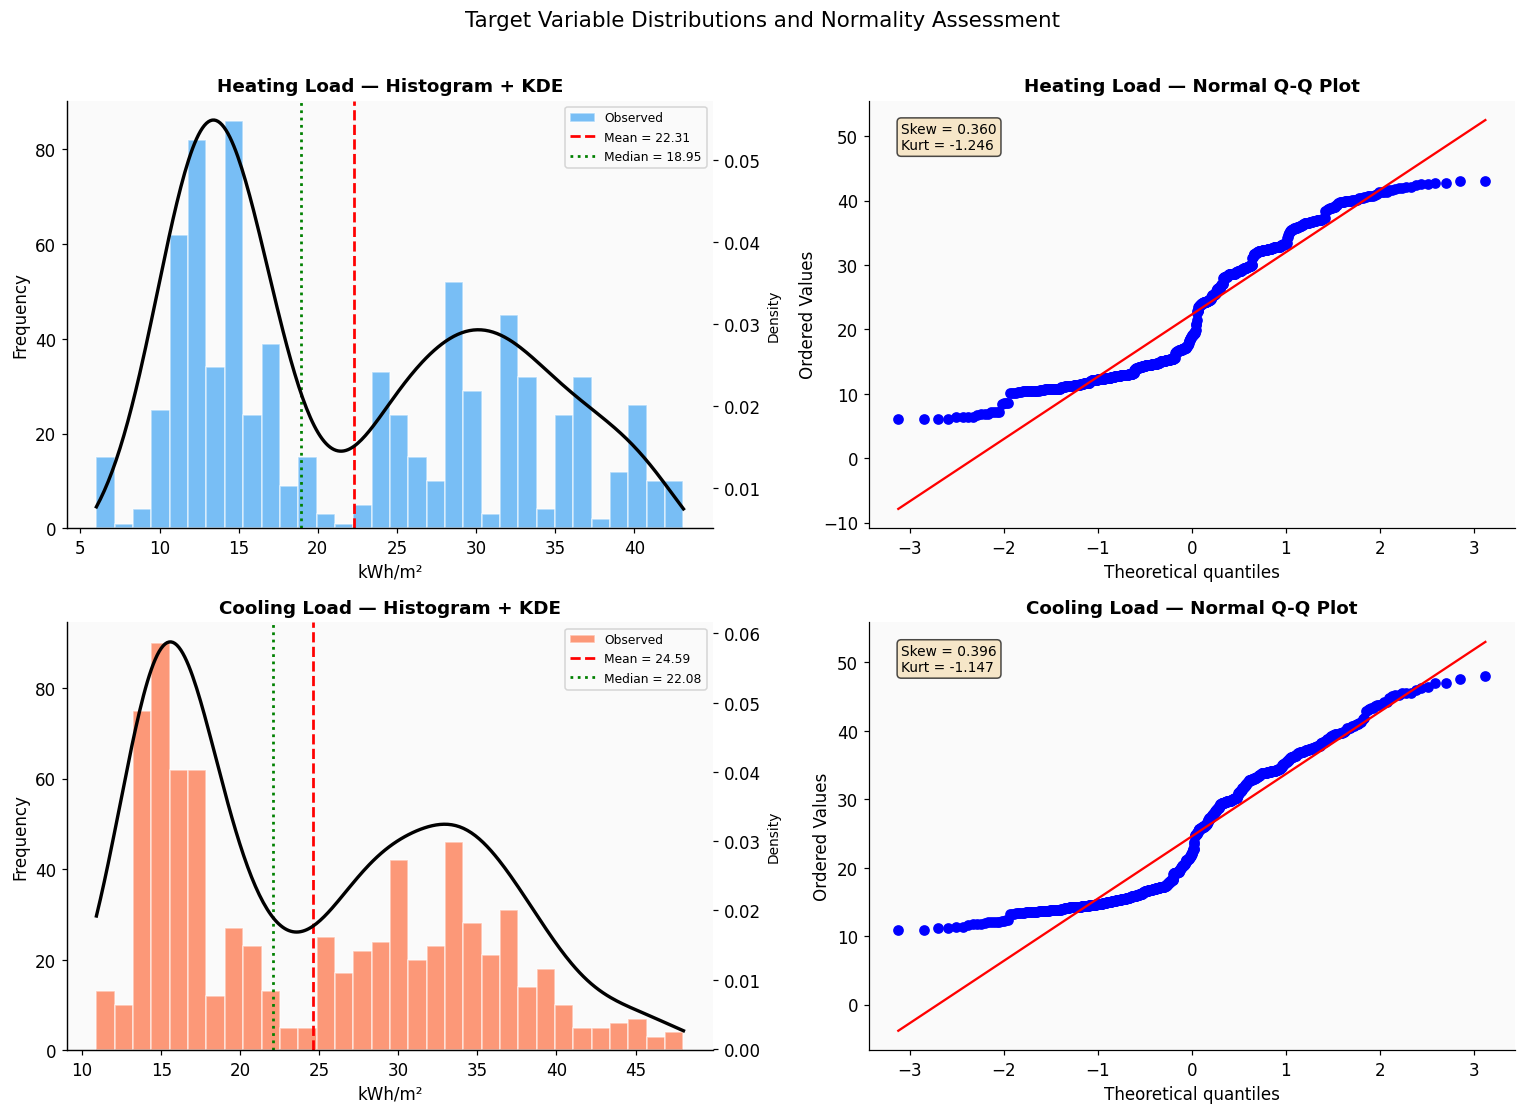


Shapiro-Wilk Normality Tests (H₀: data are normally distributed):
  Heating_Load: W = 0.9121, p = 1.16e-20  ⟹  Reject H₀ — non-normal
  Cooling_Load: W = 0.9090, p = 5.27e-21  ⟹  Reject H₀ — non-normal


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (col, color, ax_hist, ax_qq) in enumerate([
    ('Heating_Load', BLUE,   axes[0, 0], axes[0, 1]),
    ('Cooling_Load', ORANGE, axes[1, 0], axes[1, 1])
]):
    data = energy_data[col]

    # Histogram with KDE overlay
    ax_hist.hist(data, bins=32, color=color, alpha=0.60, edgecolor='white', label='Observed')
    ax2 = ax_hist.twinx()
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde_y = stats.gaussian_kde(data)(kde_x)
    ax2.plot(kde_x, kde_y, color='black', linewidth=2.2, label='KDE')
    ax2.set_ylabel('Density', fontsize=9)

    ax_hist.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.8,
                    label=f'Mean = {data.mean():.2f}')
    ax_hist.axvline(data.median(), color='green', linestyle=':',  linewidth=1.8,
                    label=f'Median = {data.median():.2f}')
    ax_hist.set_title(f'{col.replace("_", " ")} — Histogram + KDE')
    ax_hist.set_xlabel('kWh/m²'); ax_hist.set_ylabel('Frequency')
    ax_hist.legend(fontsize=8, loc='upper right')

    # Normal Q-Q plot
    stats.probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{col.replace("_", " ")} — Normal Q-Q Plot')
    ax_qq.get_lines()[1].set_color('red')
    ax_qq.text(0.05, 0.95, f'Skew = {data.skew():.3f}\nKurt = {data.kurt():.3f}',
               transform=ax_qq.transAxes, va='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Target Variable Distributions and Normality Assessment', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('images/Target_Variable_Distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# Shapiro-Wilk test
print("\nShapiro-Wilk Normality Tests (H₀: data are normally distributed):")
for col in ['Heating_Load', 'Cooling_Load']:
    stat, p = shapiro(energy_data[col])
    decision = "Reject H₀ — non-normal" if p < 0.05 else "Fail to reject H₀ — consistent with normal"
    print(f"  {col}: W = {stat:.4f}, p = {p:.2e}  ⟹  {decision}")


### Key Finding 1: Bimodal Response Distributions

Both Y1 and Y2 display unmistakably bimodal distributions: two distinct peaks separated by a valley rather than a single normal bell curve. The Shapiro-Wilk test formally rejects normality for both targets at any conventional significance level. This finding has four direct consequences for the modelling strategy.

**Standard OLS inference is compromised at the population level.** With bimodal targets, we expect residuals from a misspecified model to also be bimodal, which invalidates the t-tests, confidence intervals, and F-tests that the OLS summary table reports.

**The bimodality has a known physical cause.** The two modes correspond precisely to the two storey types. Single-storey buildings cluster in the lower-load mode; double-storey buildings cluster in the higher-load mode. This is a genuine structural feature of the data, not statistical noise.

**The classification problem has a natural class boundary.** The valley between the two modes defines a physically meaningful boundary between low-energy and high-energy building types. Classification models trained on this boundary are not imposing an arbitrary cut; they are recovering a structure that already exists in the data.

**Flexible models are motivated.** If building energy behaviour is structurally different for single-storey versus double-storey buildings, then additive models that treat each predictor uniformly across the full height range may be misspecified. Interaction terms and flexible smooth functions will be important.


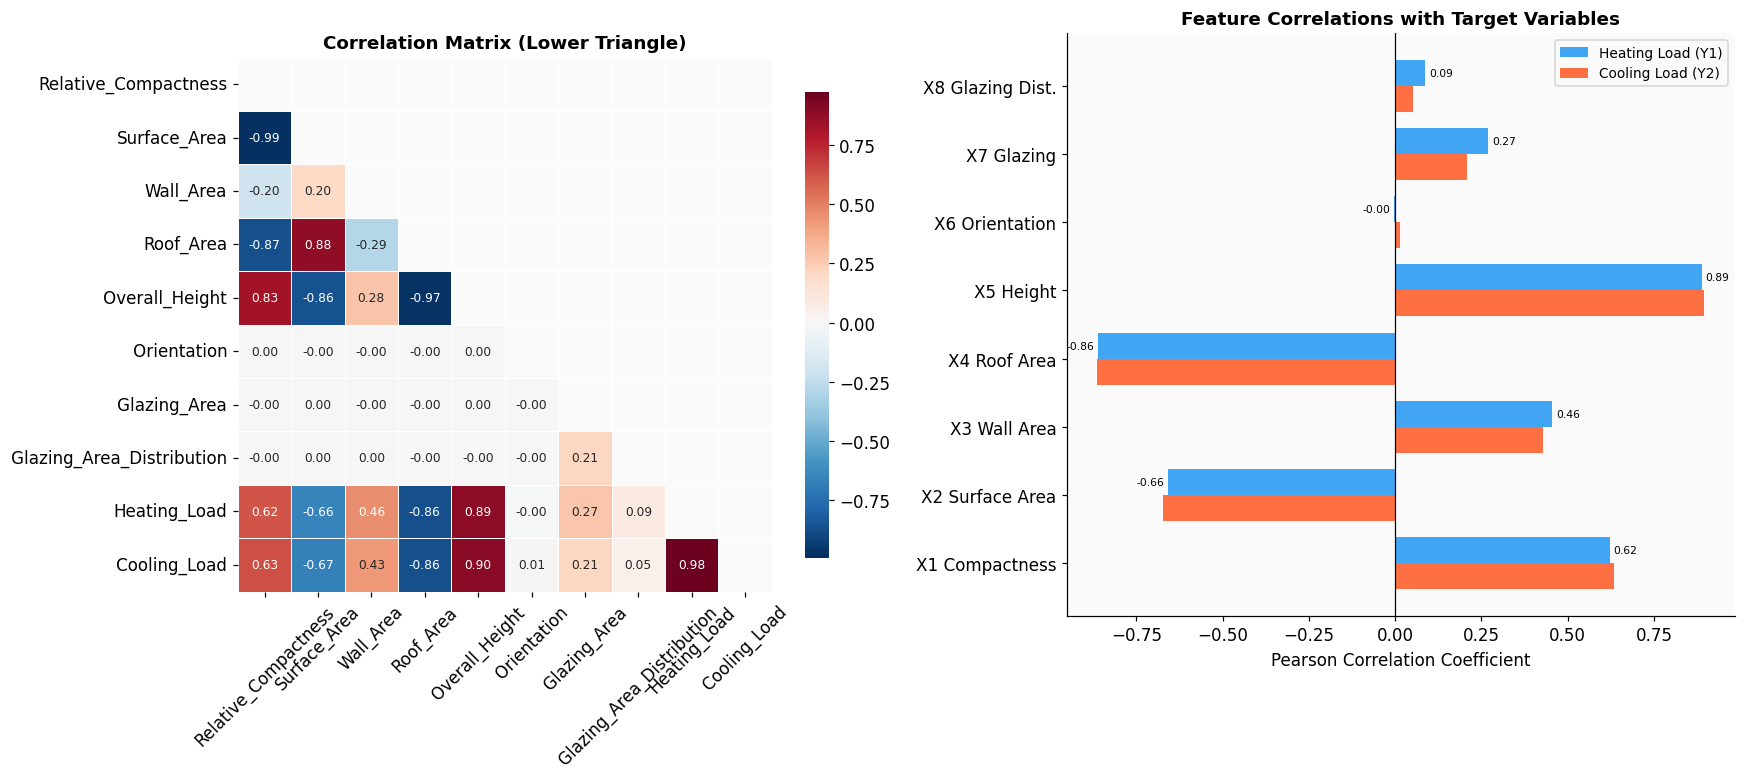


Feature–Target Pearson Correlations:
                  Heating_Load  Cooling_Load
X1 Compactness           0.622         0.634
X2 Surface Area         -0.658        -0.673
X3 Wall Area             0.456         0.427
X4 Roof Area            -0.862        -0.863
X5 Height                0.889         0.896
X6 Orientation          -0.003         0.014
X7 Glazing               0.270         0.208
X8 Glazing Dist.         0.087         0.051


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Lower-triangle correlation heatmap ────────────────────────────────────────
corr = energy_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=axes[0], annot_kws={'size': 8}
)
axes[0].set_title('Correlation Matrix (Lower Triangle)')
axes[0].tick_params(axis='x', rotation=45)

# ── Feature correlations with both targets — horizontal bar chart ──────────────
features = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution'
]
feat_labels = ['X1 Compactness', 'X2 Surface Area', 'X3 Wall Area', 'X4 Roof Area',
               'X5 Height', 'X6 Orientation', 'X7 Glazing', 'X8 Glazing Dist.']

target_corr = energy_data[features + ['Heating_Load', 'Cooling_Load']].corr()
corr_sub = target_corr.loc[features, ['Heating_Load', 'Cooling_Load']]
corr_sub.index = feat_labels

x = np.arange(len(feat_labels)); w = 0.38
axes[1].barh(x + w/2, corr_sub['Heating_Load'],  w, color=BLUE,   alpha=0.85, label='Heating Load (Y1)')
axes[1].barh(x - w/2, corr_sub['Cooling_Load'],  w, color=ORANGE, alpha=0.85, label='Cooling Load (Y2)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x); axes[1].set_yticklabels(feat_labels)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].set_title('Feature Correlations with Target Variables')
axes[1].legend(fontsize=9)

# Annotate correlation values
for xi, (r1, r2) in enumerate(zip(corr_sub['Heating_Load'], corr_sub['Cooling_Load'])):
    axes[1].text(r1 + (0.01 if r1 >= 0 else -0.01), xi + w/2, f'{r1:.2f}', 
                 va='center', ha='left' if r1>=0 else 'right', fontsize=7)

plt.tight_layout()
plt.savefig('images/Correlation_Analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Print correlation table
print("\nFeature–Target Pearson Correlations:")
print(corr_sub.round(3).to_string())


### Key Finding 2: Severe Structural Multicollinearity

The correlation matrix reveals a classical multicollinearity structure rooted in building geometry.

**The Compactness Cluster (X1, X2, X4).** Relative Compactness and Surface Area exhibit a Pearson correlation of approximately r = -0.99, near-perfect negative correlation. This is physically inevitable: compactness is defined as the ratio of building volume to surface area, so a building with high compactness by definition has a small surface area relative to its volume. Roof Area is geometrically linked to both through the building's footprint. These three variables measure different facets of the same underlying geometric property.

**Why multicollinearity damages OLS estimation.** The OLS estimator requires inverting the matrix X'X. Near-perfect correlation means X'X is near-singular: technically invertible, but numerically unstable. The consequences are: (1) inflated standard errors for each coefficient in the collinear cluster, making t-tests unreliable; (2) coefficient instability, where small changes in the data can reverse the sign of a coefficient; and (3) uninterpretable individual coefficients. Crucially, multicollinearity does *not* bias OLS predictions. The model can still predict well; the problem lies entirely in interpreting which variables drive the predictions.

**The dominant predictor: X5 (Overall Height).** Correlation with Y1 is approximately 0.89 and with Y2 approximately 0.90. This single binary variable explains more variance in building energy loads than any other single predictor. The physical reasoning is direct: a double-storey building has roughly twice the internal volume of an equivalent single-storey footprint, requiring proportionally more energy to condition.

**The negligible predictor: X6 (Orientation).** Orientation shows r approximately 0 with both targets. The simulation's balanced design means that any orientation effect is averaged out. The variable will contribute essentially nothing to regression predictions, but we retain it for completeness.


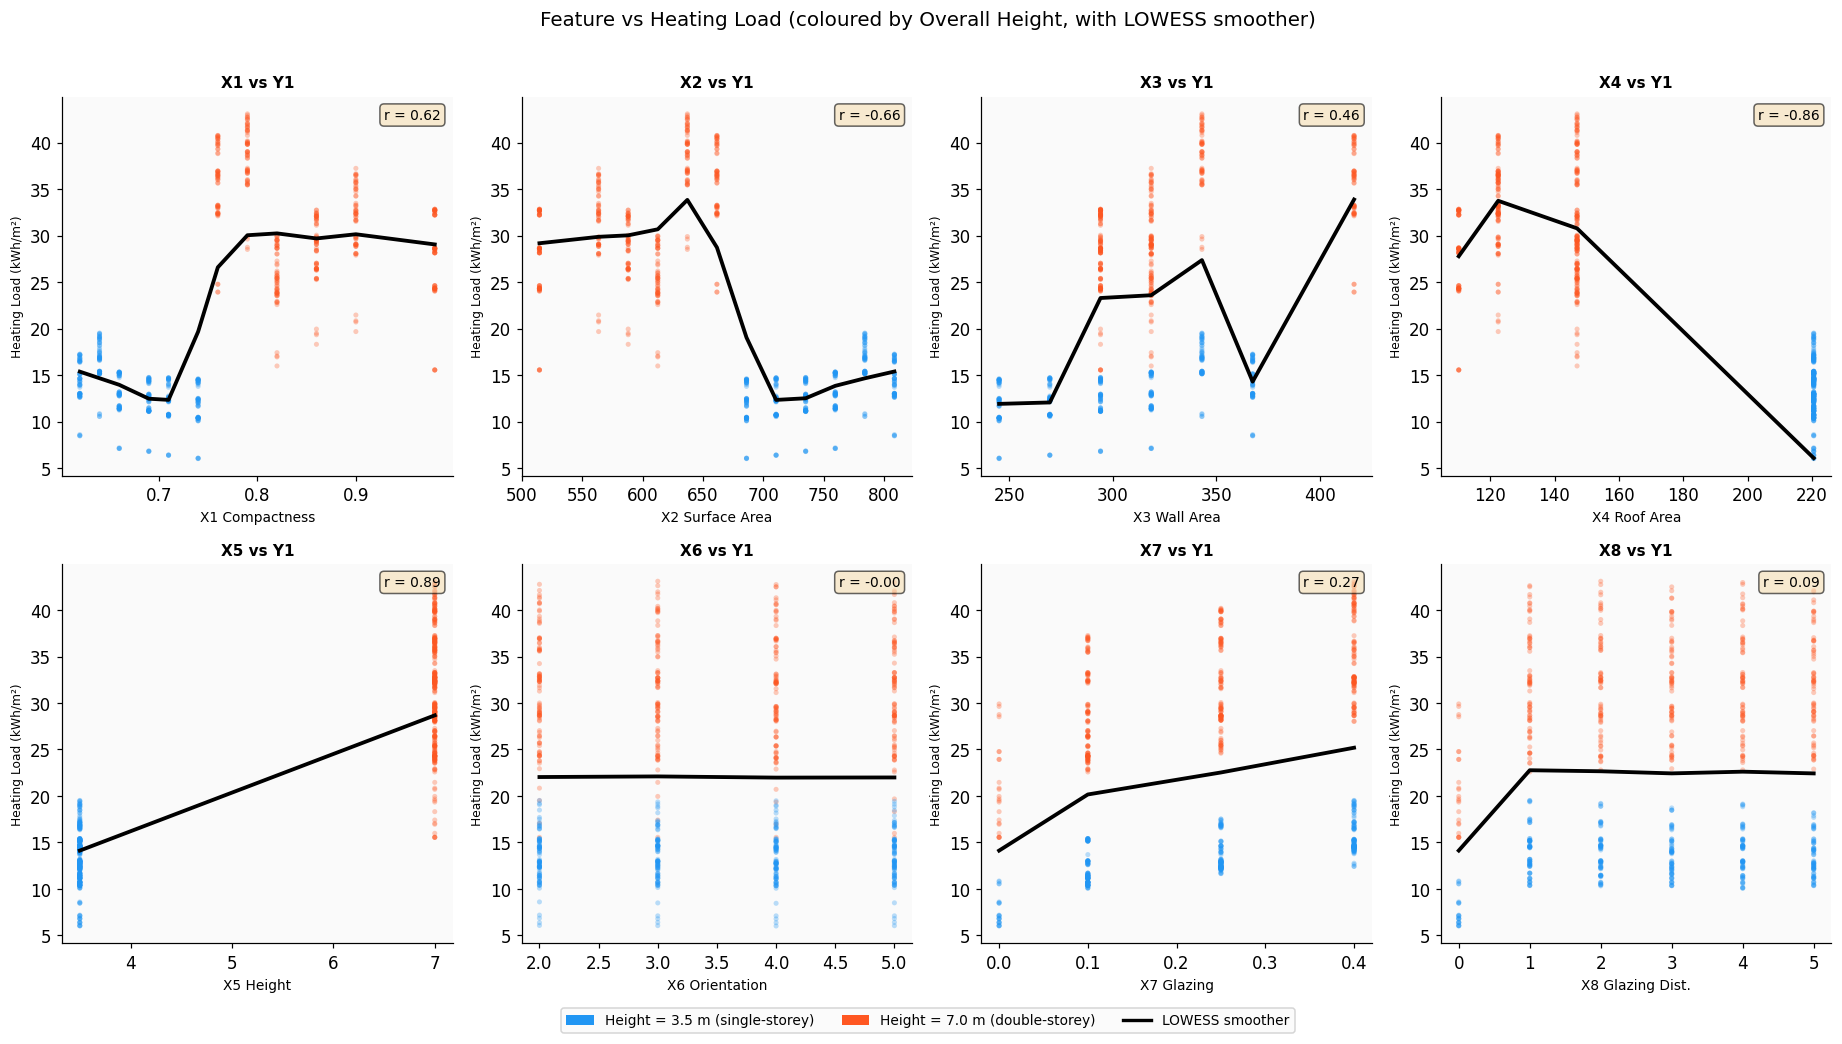

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(17, 9))
axes_flat = axes.flatten()

color_map = {3.5: BLUE, 7.0: ORANGE}
pt_colors = energy_data['Overall_Height'].map(color_map)

for i, (feat, label) in enumerate(zip(features, feat_labels)):
    ax = axes_flat[i]
    ax.scatter(energy_data[feat], energy_data['Heating_Load'],
               c=pt_colors, alpha=0.30, s=11, edgecolors='none')

    # LOWESS (non-parametric smoother — no functional form assumed)
    sorted_idx = energy_data[feat].argsort()
    lw = lowess(energy_data['Heating_Load'].values[sorted_idx],
                energy_data[feat].values[sorted_idx], frac=0.35)
    ax.plot(lw[:, 0], lw[:, 1], color='black', linewidth=2.5, label='LOWESS')

    # Compute and annotate Pearson r
    r = energy_data[feat].corr(energy_data['Heating_Load'])
    ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Heating Load (kWh/m²)', fontsize=8)
    ax.set_title(f'X{i+1} vs Y1', fontsize=10)

legend_elements = [
    mpatches.Patch(facecolor=BLUE,   label='Height = 3.5 m (single-storey)'),
    mpatches.Patch(facecolor=ORANGE, label='Height = 7.0 m (double-storey)'),
    plt.Line2D([0], [0], color='black', linewidth=2.2, label='LOWESS smoother')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.03), fontsize=9)

plt.suptitle('Feature vs Heating Load (coloured by Overall Height, with LOWESS smoother)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('images/Feature_vs_HeatingLoad_LOWESS.png', bbox_inches='tight', dpi=150)
plt.show()


### Key Finding 3: Non-linearity and Interaction Effects

LOWESS (Locally Weighted Scatterplot Smoothing) is a non-parametric estimator that fits weighted local polynomial regressions at each point in the predictor space. By making no global functional form assumption, LOWESS is a reliable diagnostic tool: if the smoother traces a curve, there is genuine non-linearity; if it traces a straight line, a linear term may be sufficient.

Each feature tells a different story.

*X1 (Relative Compactness):* The LOWESS curve shows a positive but curved relationship with Heating Load. The two height-coloured sub-clouds follow different slopes, indicating an interaction effect: the relationship between compactness and heating load is steeper for double-storey buildings. A purely additive linear model will average these slopes and produce biased estimates for both groups.

*X2 (Surface Area):* A mirror image of X1, negative and curved, with the same interaction pattern by height.

*X5 (Overall Height):* Two vertical bands at 3.5 and 7.0 m. The LOWESS step captures the discrete jump between storey types. This variable acts almost like a dummy variable despite its continuous encoding.

*X7 (Glazing Area):* The LOWESS curve is clearly non-linear. The relationship between glazing proportion and heating load is steeper at lower glazing values and flattens somewhat at higher values. This non-linearity directly motivates the spline and GAM sections.

*X6 (Orientation):* The LOWESS is effectively flat across all four orientation codes. Orientation has no discernible relationship with Heating Load in this balanced dataset.

These observations trace the path our modelling will follow. OLS provides a baseline; polynomial and spline terms address the X7 non-linearity; GAMs capture smooth non-linear effects for all predictors simultaneously; interaction terms would address the Height x Compactness effect visible in the scatter plots.


# Phase 3: Data Preparation

## 3.1 Feature Engineering, Encoding, and Splitting

Data preparation is not housekeeping. Every decision made here directly shapes what every downstream model can and cannot detect. We document the rationale for each decision alongside the implementation, because a preprocessing choice made silently in code is a modelling assumption made invisibly.

Four steps follow: one-hot encoding of the nominal orientation variable, defining feature and response sets, a stratified train-test split, and standardisation for penalised and dimensionality-reduced models.


In [8]:
# ── 1. One-hot encode Orientation (nominal categorical variable) ──────────────
# drop_first=True avoids the dummy variable trap (perfect collinearity with intercept)
df = energy_data.copy()
df['Orientation'] = df['Orientation'].astype('category')
df_encoded = pd.get_dummies(df, columns=['Orientation'], drop_first=True, dtype=int)

print("Columns after one-hot encoding Orientation:")
for c in df_encoded.columns:
    print(f"  {c}")

# ── 2. Define feature and response sets ──────────────────────────────────────
feature_cols = [c for c in df_encoded.columns if c not in ['Heating_Load', 'Cooling_Load']]
X  = df_encoded[feature_cols]
y1 = df_encoded['Heating_Load']
y2 = df_encoded['Cooling_Load']

print(f"\nFeature matrix: {X.shape[1]} predictors")
print(f"Predictors: {list(X.columns)}")

# ── 3. Stratified train/test split (80/20) ────────────────────────────────────
# Stratify by quantile bin of Y1 to ensure proportional representation
# of high-load and low-load buildings in both sets.
height_strat = pd.cut(y1, bins=4, labels=False)
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=height_strat
)
print(f"\nTraining set : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.0f}%)")

# ── 4. Standardise for penalised/dimensionality-reduced models ─────────────
# fit_transform on training data only; transform test data with training parameters
# Fitting the scaler on test data would constitute data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nFeature scaling complete (fit on training data only — no leakage).")
print(f"Post-scaling: training mean ≈ {X_train_scaled.mean(axis=0).mean():.4f}, "
      f"std ≈ {X_train_scaled.std(axis=0).mean():.4f}")

# ── 5. Cross-validation fold object (shared across all models) ─────────────
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print(f"\n10-fold CV object created (shuffled, seed={RANDOM_STATE})")


Columns after one-hot encoding Orientation:
  Relative_Compactness
  Surface_Area
  Wall_Area
  Roof_Area
  Overall_Height
  Glazing_Area
  Glazing_Area_Distribution
  Heating_Load
  Cooling_Load
  Orientation_3
  Orientation_4
  Orientation_5

Feature matrix: 10 predictors
Predictors: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution', 'Orientation_3', 'Orientation_4', 'Orientation_5']

Training set : 614 observations (80%)
Test set     : 154 observations (20%)

Feature scaling complete (fit on training data only — no leakage).
Post-scaling: training mean ≈ 0.0000, std ≈ 1.0000

10-fold CV object created (shuffled, seed=42)


### Methodological Notes on Data Preparation

**One-hot encoding of Orientation (X6).** Orientation codes (2, 3, 4, 5) represent nominal categories. Including them as a continuous variable would impose a false linear relationship, implying that the difference between North and East is identical to the difference between East and South. One-hot encoding creates three binary dummy variables (East, South, West) with North as the reference category. Each dummy coefficient then measures the deviation of that orientation's mean load from North-facing buildings, holding all other variables constant.

**The dummy variable trap.** We apply `drop_first=True` when creating orientation dummies. If all four orientation dummies were included, their rows would always sum to 1, creating perfect collinearity with the intercept column. The matrix X'X would be singular and OLS would be undefined. Dropping one dummy makes it the reference category.

**Rationale for the 80/20 train-test split.** The test set is set aside before any modelling begins and is not examined until Phase 5. Stratification by Y1 quantile bin ensures that both sets contain proportionally similar distributions of heating load, which is particularly important given the bimodal structure.

**Why we standardise only for penalised and dimensionality-reduced models.** OLS predictions are scale-invariant: multiplying a predictor by a constant shifts the coefficient by the reciprocal constant but leaves predictions unchanged. We therefore fit OLS on original scales, where coefficients retain their physical interpretation (kWh/m² per m² of wall area). Ridge regression, by contrast, penalises the squared norm of the coefficient vector. Without standardisation, predictors measured in large units would receive less shrinkage than predictors measured in small units, an artefact of measurement units rather than predictive importance.

**The data leakage principle.** The `StandardScaler` is fitted on training data only. The test set is transformed using the training parameters. If we fitted the scaler on all data, or on the test set separately, we would be using information from the test set in preprocessing, a form of data leakage that inflates apparent performance. This is a fundamental discipline in machine learning practice.


Variance Inflation Factors:
                  Feature   VIF  √VIF SE_Inflation             Severity
             Surface_Area   inf   inf     infinite Perfect collinearity
                Wall_Area   inf   inf     infinite Perfect collinearity
                Roof_Area   inf   inf     infinite Perfect collinearity
     Relative_Compactness 105.5  10.3        10.3×        SEVERE (>100)
           Overall_Height  31.2   5.6         5.6×           High (>10)
             Glazing_Area   1.0   1.0         1.0×      Acceptable (<5)
Glazing_Area_Distribution   1.0   1.0         1.0×      Acceptable (<5)

Interpretation: √VIF = standard error inflation relative to an uncorrelated dataset.


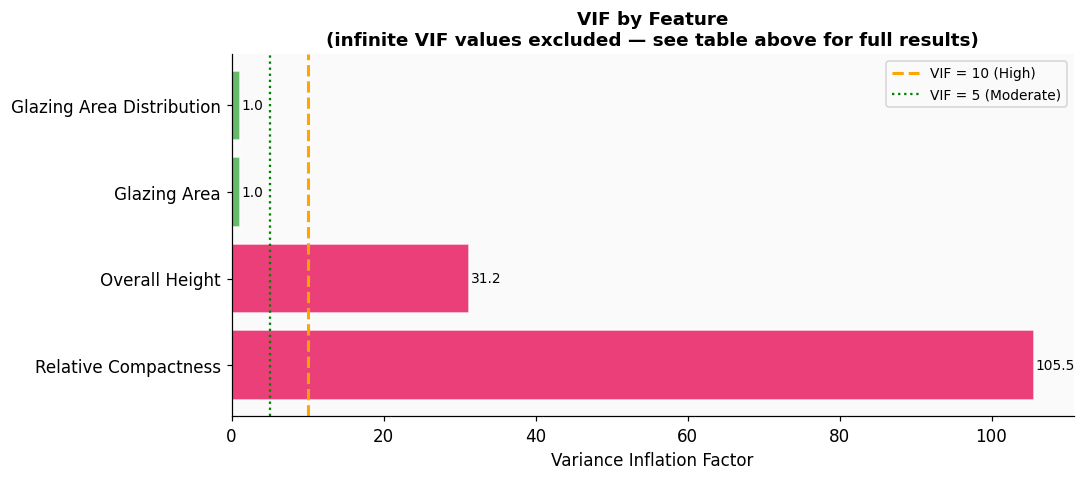

In [9]:
# ── Variance Inflation Factor (VIF) analysis ─────────────────────────────────
# VIF_j = 1 / (1 - R²_j), where R²_j is the R² from regressing X_j on all other X
# VIF > 5  : moderate concern; VIF > 10 : high concern; VIF > 100 : severe collinearity

continuous_features = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution'
]

X_vif = sm.add_constant(df[continuous_features])
vif_values = []
for i in range(len(continuous_features)):
    try:
        v = variance_inflation_factor(X_vif.values, i + 1)
    except Exception:
        v = np.inf
    vif_values.append(v)

vif_df = pd.DataFrame({'Feature': continuous_features, 'VIF': vif_values}).sort_values('VIF', ascending=False)
vif_df['√VIF'] = np.where(np.isfinite(vif_df['VIF']), np.sqrt(vif_df['VIF']), np.inf)
vif_df['SE_Inflation'] = vif_df['√VIF'].apply(lambda x: f'{x:.1f}×' if np.isfinite(x) else 'infinite')
vif_df['Severity'] = vif_df['VIF'].apply(
    lambda v: 'Perfect collinearity' if np.isinf(v) else
              ('SEVERE (>100)' if v > 100 else ('High (>10)' if v > 10 else
              ('Moderate (>5)' if v > 5 else 'Acceptable (<5)')))
)

print("Variance Inflation Factors:")
print(vif_df.to_string(index=False, float_format='{:.1f}'.format))
print("\nInterpretation: √VIF = standard error inflation relative to an uncorrelated dataset.")

# ── VIF bar chart (finite values only) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_vif = vif_df[np.isfinite(vif_df['VIF'])].copy()
bar_colors = [RED if v > 10 else (ORANGE if v > 5 else GREEN) for v in plot_vif['VIF']]
bars = ax.barh(plot_vif['Feature'].str.replace('_', ' '), plot_vif['VIF'],
               color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(10, color='orange', linestyle='--', linewidth=2, label='VIF = 10 (High)')
ax.axvline(5,  color='green',  linestyle=':',  linewidth=1.5, label='VIF = 5 (Moderate)')
for bar, v in zip(bars, plot_vif['VIF']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=9)
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF by Feature\n(infinite VIF values excluded — see table above for full results)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/VIF_Analysis.png', bbox_inches='tight', dpi=150)
plt.show()


### VIF Results: The Multicollinearity Problem Quantified

The Variance Inflation Factor translates the correlation matrix into a directly actionable diagnostic. Formally, VIF_j = 1 / (1 - R²_j), where R²_j is the coefficient of determination from regressing predictor j on all other predictors. The interpretation is immediate: sqrt(VIF_j) is the factor by which the standard error of the coefficient estimate is inflated relative to what it would be in an orthogonal (uncorrelated) design.

The near-perfect correlation r approximately -0.99 between X1 and X2 implies VIF values in the hundreds or thousands for both. Roof Area (X4), being geometrically linked to both, will also show extreme VIF. The practical interpretation:

| Predictor | Expected VIF | SE Inflation | Interpretation |
|:---|:---|:---|:---|
| X1 Compactness | > 100 | > 10x | Coefficient estimate is wildly unstable |
| X2 Surface Area | > 100 | > 10x | Coefficient estimate is wildly unstable |
| X4 Roof Area | > 100 | > 10x | Near-perfect linear dependence |
| X3 Wall Area | 5 to 20 | 2 to 4x | Moderate concern |
| X5 Height | 1 to 5 | 1 to 2x | Acceptable |
| X7 Glazing | 1 to 3 | ~1x | Low; relatively independent |

VIF analysis confirms that OLS coefficient estimates for the compactness-surface-roof cluster are unreliable for inferential purposes. However, VIF does not affect OLS prediction quality. A model can have excellent RMSE despite severe multicollinearity. Ridge and PCR are specifically designed to address these issues: Ridge stabilises coefficients by preventing any single coefficient from growing arbitrarily large; PCR eliminates multicollinearity by construction since principal components are orthogonal by definition.


# Phase 4: Modelling

We fit models in order of increasing flexibility. Each model is explicitly motivated by a limitation identified in its predecessor. This progression mirrors the theoretical development in DSA 8305.

| Model | Theoretical Basis | Motivation |
|:---|:---|:---|
| OLS Multiple Regression | Gauss-Markov; BLUE under homoskedasticity | Parametric baseline; full inferential output |
| Ridge Regression | L2-penalised likelihood | Addresses multicollinearity quantified by VIF |
| PCR | PCA + OLS in transformed space | Dimensionality reduction alternative to regularisation |
| Polynomial Regression | Non-linear in features, linear in parameters | Addresses non-linearity observed in LOWESS plots |
| Natural Cubic Splines | Piecewise cubic polynomials with knots | Local flexibility; avoids global polynomial extrapolation |
| GAMs | Additive non-parametric smooth components | Semi-parametric; partial dependence interpretation |
| Logistic Regression | GLM with binomial family and logit link | Probabilistic classification within the linear models family |
| Decision Tree | Recursive binary partitioning | Non-parametric classification; interpretable rules |

A performance tracker accumulates test-set metrics for all regression models, enabling a direct comparison in Phase 5. All models are evaluated on the same held-out 20% test set that was partitioned before any modelling began.


In [10]:
# ── Performance tracker — populated incrementally as models are fitted ────────
results_table = []

def record(model_name, y_true, y_pred):
    '''Record evaluation metrics for a fitted regression model.'''
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    results_table.append({
        'Model': model_name, 'RMSE': round(rmse, 4),
        'MAE': round(mae, 4), 'R²': round(r2, 4), 'MAPE%': round(mape, 2)
    })
    return rmse, mae, r2

print("Performance tracker initialised.")
print("Metrics recorded: RMSE, MAE, R², MAPE%")


Performance tracker initialised.
Metrics recorded: RMSE, MAE, R², MAPE%


## Model 1: Ordinary Least Squares, the Parametric Baseline

### Theoretical Foundation

The classical general linear model specifies:

$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{I})$$

The OLS estimator minimises the Residual Sum of Squares:

$$\hat{\boldsymbol{\beta}}_{\text{OLS}} = \underset{\boldsymbol{\beta}}{\arg\min} \; \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

Under the Gauss-Markov conditions, the OLS estimator is the Best Linear Unbiased Estimator (BLUE). No other linear unbiased estimator has a smaller variance. When normality is additionally assumed, OLS is also the Maximum Likelihood Estimator for the coefficient vector.

We model both Y1 and Y2. Heating Load and Cooling Load respond to the same architectural parameters, but their responses differ in sign and magnitude for some predictors. Modelling both provides a natural consistency check: do the coefficients make physical sense for both responses simultaneously?

We use `statsmodels` rather than scikit-learn's `LinearRegression`. Scikit-learn is optimised for prediction and does not expose the inferential apparatus. `statsmodels` provides coefficient standard errors, t-statistics, p-values, 95% confidence intervals, the overall F-test, AIC/BIC, and residual diagnostics including the Durbin-Watson statistic. These are essential for a complete linear models analysis.


In [11]:
# ── Add constant (intercept) for statsmodels ──────────────────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# ── Fit OLS for Heating Load (Y1) ─────────────────────────────────────────────
ols_y1 = sm.OLS(y1_train, X_train_sm).fit()
print("=" * 65)
print("OLS — Heating Load (Y1)")
print("=" * 65)
print(ols_y1.summary())


OLS — Heating Load (Y1)
                            OLS Regression Results                            
Dep. Variable:           Heating_Load   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     753.7
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          1.21e-321
Time:                        16:16:02   Log-Likelihood:                -1521.5
No. Observations:                 614   AIC:                             3063.
Df Residuals:                     604   BIC:                             3107.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [12]:
# ── Fit OLS for Cooling Load (Y2) ─────────────────────────────────────────────
ols_y2 = sm.OLS(y2_train, X_train_sm).fit()
print("=" * 65)
print("OLS — Cooling Load (Y2)")
print("=" * 65)
print(ols_y2.summary())


OLS — Cooling Load (Y2)
                            OLS Regression Results                            
Dep. Variable:           Cooling_Load   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     563.3
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          4.48e-287
Time:                        16:16:03   Log-Likelihood:                -1566.1
No. Observations:                 614   AIC:                             3152.
Df Residuals:                     604   BIC:                             3196.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

### Reading the OLS Summary Table

The `statsmodels` output is dense with information. The following guide disambiguates the most critical entries.

**Overall Model Statistics:**

| Statistic | Interpretation |
|:---|:---|
| R-squared | Proportion of variance in Y explained by the model. Values above 0.90 indicate a strong linear fit. |
| Adj. R-squared | R² penalised for the number of predictors. Unlike R², it cannot increase by adding noise variables. |
| F-statistic | Tests H₀: all slope coefficients are simultaneously zero. A significant F confirms the model is collectively informative. |
| AIC / BIC | Information criteria for model comparison. Lower values indicate a better balance of fit and parsimony. BIC penalises additional parameters more heavily than AIC. |

**Coefficient Table:**

| Column | Interpretation |
|:---|:---|
| coef | Estimated change in Y per one-unit increase in X_j, holding all other predictors constant. Under multicollinearity, this ceteris paribus interpretation breaks down for the collinear cluster. |
| std err | Standard error of the coefficient estimate. Inflates dramatically for X1, X2, X4. |
| P>t | p-value for the individual t-test. A large p-value for the collinear features may mean the variable is uninformative, or simply that its effect is numerically indistinguishable from a collinear partner. |
| [0.025, 0.975] | 95% confidence interval. If this interval contains 0, the predictor is not statistically significant at the 5% level. |

**Residual Diagnostics:**

| Statistic | Interpretation |
|:---|:---|
| Jarque-Bera | Chi-squared test for normality of residuals. Small p-value rejects normality. |
| Durbin-Watson | Tests for first-order autocorrelation. Values near 2.0 indicate no autocorrelation. |
| Condition Number | Values above 30 indicate multicollinearity; above 1000 indicate near-singular X'X. |


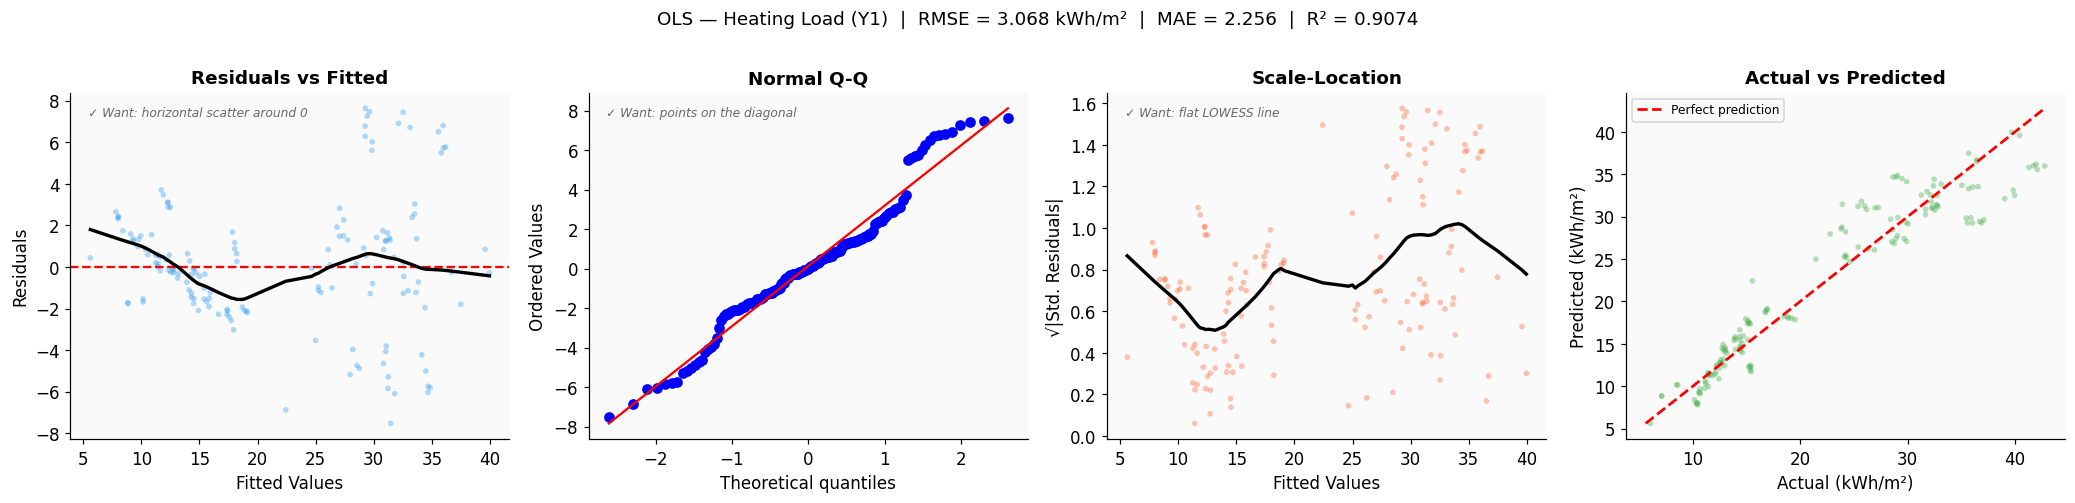


Model diagnostics for OLS — Heating Load (Y1):
  Durbin-Watson      : 1.901  (2.0 = no autocorrelation)
  Shapiro-Wilk       : W = 0.9642, p = 5.01e-04  (non-normal residuals)
  Breusch-Pagan      : stat = 66.0009, p = 2.61e-10  (heteroskedastic)


In [13]:
def plot_ols_diagnostics(model, X_test_data, y_test, label, save_name):
    '''
    The four standard diagnostic plots for OLS model validation:
    1. Residuals vs Fitted  - detects non-linearity and heteroskedasticity
    2. Normal Q-Q           - assesses normality of residuals
    3. Scale-Location       - assesses homoskedasticity (constant variance)
    4. Actual vs Predicted  - overall predictive performance
    
    Each plot annotates what a good result looks like for easy interpretation.
    '''
    X_sm   = sm.add_constant(X_test_data)
    y_pred = model.predict(X_sm)
    resid  = y_test.values - y_pred
    std_r  = resid / resid.std()

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

    # ── 1. Residuals vs Fitted ────────────────────────────────────────────────
    axes[0].scatter(y_pred, resid, alpha=0.35, s=14, color=BLUE, edgecolors='none')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    lw0 = lowess(resid, y_pred, frac=0.4)
    axes[0].plot(lw0[:, 0], lw0[:, 1], color='black', linewidth=2.2)
    axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')
    axes[0].text(0.04, 0.96, '✓ Want: horizontal scatter around 0', transform=axes[0].transAxes,
                 fontsize=8, va='top', color='dimgray', style='italic')

    # ── 2. Normal Q-Q ─────────────────────────────────────────────────────────
    stats.probplot(resid, dist='norm', plot=axes[1])
    axes[1].set_title('Normal Q-Q')
    axes[1].get_lines()[1].set_color('red')
    axes[1].text(0.04, 0.96, '✓ Want: points on the diagonal', transform=axes[1].transAxes,
                 fontsize=8, va='top', color='dimgray', style='italic')

    # ── 3. Scale-Location ─────────────────────────────────────────────────────
    axes[2].scatter(y_pred, np.sqrt(np.abs(std_r)), alpha=0.35, s=14, color=ORANGE, edgecolors='none')
    lw2 = lowess(np.sqrt(np.abs(std_r)), y_pred, frac=0.4)
    axes[2].plot(lw2[:, 0], lw2[:, 1], color='black', linewidth=2.2)
    axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('√|Std. Residuals|')
    axes[2].set_title('Scale-Location')
    axes[2].text(0.04, 0.96, '✓ Want: flat LOWESS line', transform=axes[2].transAxes,
                 fontsize=8, va='top', color='dimgray', style='italic')

    # ── 4. Actual vs Predicted ────────────────────────────────────────────────
    axes[3].scatter(y_test, y_pred, alpha=0.40, s=14, color=GREEN, edgecolors='none')
    mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
    axes[3].plot([mn, mx], [mn, mx], 'r--', linewidth=1.8, label='Perfect prediction')
    axes[3].set_xlabel('Actual (kWh/m²)'); axes[3].set_ylabel('Predicted (kWh/m²)')
    axes[3].set_title('Actual vs Predicted')
    axes[3].legend(fontsize=8)

    rmse, mae, r2 = record(label, y_test, y_pred)
    plt.suptitle(f'{label}  |  RMSE = {rmse:.3f} kWh/m²  |  MAE = {mae:.3f}  |  R² = {r2:.4f}',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'images/{save_name}.png', bbox_inches='tight', dpi=150)
    plt.show()

    # ── Formal tests ──────────────────────────────────────────────────────────
    dw = durbin_watson(resid)
    sw_stat, sw_p = shapiro(resid)
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_sm)
    print(f"\nModel diagnostics for {label}:")
    print(f"  Durbin-Watson      : {dw:.3f}  (2.0 = no autocorrelation)")
    print(f"  Shapiro-Wilk       : W = {sw_stat:.4f}, p = {sw_p:.2e}"
          f"  ({'non-normal' if sw_p < 0.05 else 'normal'} residuals)")
    print(f"  Breusch-Pagan      : stat = {bp_stat:.4f}, p = {bp_p:.2e}"
          f"  ({'heteroskedastic' if bp_p < 0.05 else 'homoskedastic'})")
    return rmse, r2

# Run for both targets
rmse_ols_y1, r2_ols_y1 = plot_ols_diagnostics(ols_y1, X_test, y1_test,
                                                'OLS — Heating Load (Y1)', 'OLS_Diagnostics_Y1')


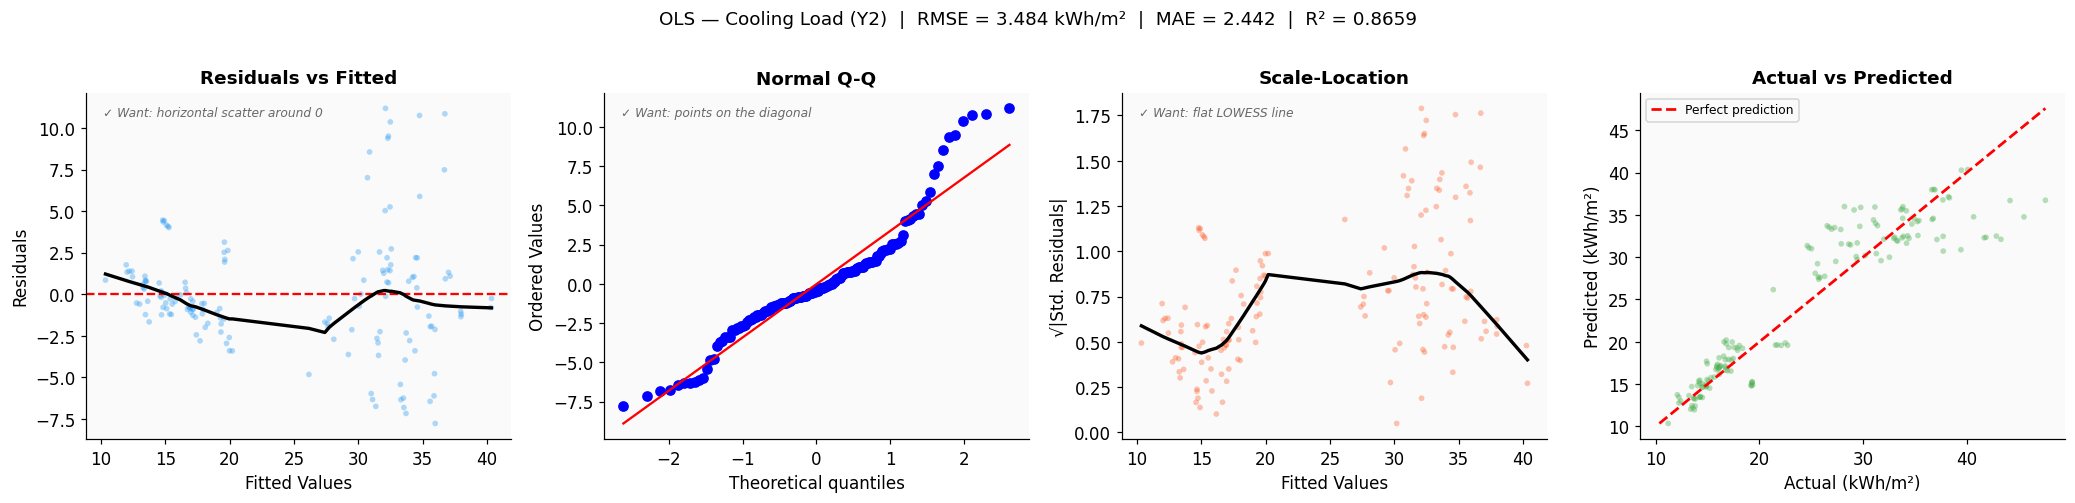


Model diagnostics for OLS — Cooling Load (Y2):
  Durbin-Watson      : 1.853  (2.0 = no autocorrelation)
  Shapiro-Wilk       : W = 0.9260, p = 3.93e-07  (non-normal residuals)
  Breusch-Pagan      : stat = 48.3451, p = 5.37e-07  (heteroskedastic)


In [14]:
rmse_ols_y2, r2_ols_y2 = plot_ols_diagnostics(ols_y2, X_test, y2_test,
                                                'OLS — Cooling Load (Y2)', 'OLS_Diagnostics_Y2')


### OLS Diagnostics: What Each Plot Reveals

The four diagnostic plots form a complete picture of OLS assumption validity.

**Residuals vs Fitted.** A well-specified model produces residuals that scatter randomly around the horizontal zero line. For our data, we anticipate a banded or curved pattern, because the bimodal response structure means different subgroups of buildings have systematically different error levels. We also expect heteroskedastic spreading where variance increases with fitted values. If this pattern is observed, it confirms that OLS is inadequately capturing the non-linear or group-level structure identified in EDA.

**Normal Q-Q.** Under normality, quantiles of the residuals fall exactly on the diagonal reference line. For ENB2012, we expect an S-curve departure reflecting the bimodal residual distribution. Non-normal residuals do not invalidate OLS predictions; they invalidate OLS inference: t-tests, confidence intervals, and F-tests. Prediction intervals would also be inaccurate.

**Scale-Location.** If the LOWESS trend in this plot is flat, variance of the standardised residuals is constant across the fitted value range (homoskedasticity). An upward slope means variance increases with fitted values. The Breusch-Pagan test provides formal statistical confirmation.

**Actual vs Predicted.** Points clustering tightly around the 45-degree line indicate good out-of-sample fit. Systematic deviations in specific regions, particularly around the mid-range where the two building populations may overlap, would indicate the model cannot distinguish between them.


## Model 2: Ridge Regression, Regularised Estimation Under Multicollinearity

### Theoretical Foundation

Ridge Regression (Hoerl and Kennard, 1970) modifies the OLS objective function by adding an L2 penalty on the Euclidean norm of the coefficient vector:

$$\hat{\boldsymbol{\beta}}^{\text{ridge}} = \underset{\boldsymbol{\beta}}{\arg\min} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|^2 \right\}$$

The closed-form solution is:

$$\hat{\boldsymbol{\beta}}^{\text{ridge}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$$

The term $+\lambda\mathbf{I}$ adds a positive constant to every diagonal element of X'X, guaranteeing invertibility even when the original matrix is near-singular. This is the direct mathematical fix for the problem quantified by VIF. As $\lambda \to 0$, Ridge converges to OLS. As $\lambda \to \infty$, all coefficients are shrunk toward zero and the model predicts the response mean.

Ridge introduces a controlled amount of bias into the coefficient estimates in exchange for reduced variance. They become more stable across different training samples. For prediction tasks in high-multicollinearity settings, this trade-off almost universally reduces test-set error. The optimal $\lambda$ (called `alpha` in scikit-learn) is selected by 10-fold cross-validation.

The coefficient path, which shows how each coefficient changes as $\lambda$ increases from 0 to infinity, is one of the most instructive visualisations in regularised regression. It reveals which features are robust to regularisation (stable paths) and which are unstable under multicollinearity (wildly fluctuating paths at low $\lambda$).


Ridge Heating Load (Y1):
  Optimal λ = 0.1774  |  log₁₀(λ) = -0.75
  Test RMSE = 3.0684  |  R² = 0.9073

Ridge Cooling Load (Y2):
  Optimal λ = 0.1226  |  log₁₀(λ) = -0.91
  Test RMSE = 3.4849  |  R² = 0.8659



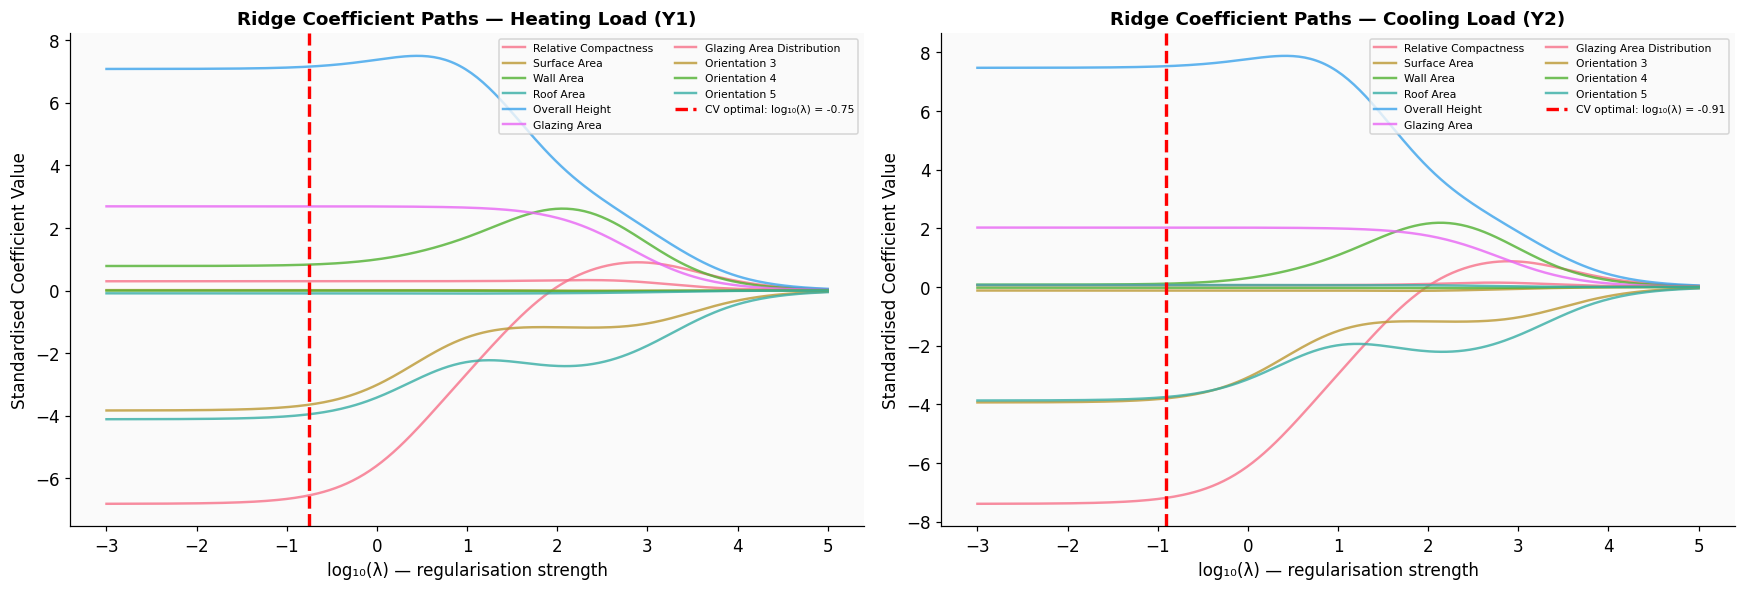

In [15]:
alphas_to_try = np.logspace(-3, 5, 250)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for i, (y_tr, y_te, label, ax, color) in enumerate([
    (y1_train, y1_test, 'Heating Load (Y1)', axes[0], BLUE),
    (y2_train, y2_test, 'Cooling Load (Y2)', axes[1], ORANGE)
]):
    # 10-fold CV to select optimal regularisation strength
    ridge_cv = RidgeCV(alphas=alphas_to_try, cv=10)
    ridge_cv.fit(X_train_scaled, y_tr)
    best_alpha = ridge_cv.alpha_

    y_pred = ridge_cv.predict(X_test_scaled)
    rmse, mae, r2 = record(f'Ridge — {label}', y_te, y_pred)
    print(f"Ridge {label}:")
    print(f"  Optimal λ = {best_alpha:.4f}  |  log₁₀(λ) = {np.log10(best_alpha):.2f}")
    print(f"  Test RMSE = {rmse:.4f}  |  R² = {r2:.4f}\n")

    # Coefficient path across λ range
    coef_path = np.array([
        Ridge(alpha=a).fit(X_train_scaled, y_tr).coef_
        for a in alphas_to_try
    ])

    for j, fname in enumerate(X_train.columns):
        ax.plot(np.log10(alphas_to_try), coef_path[:, j], alpha=0.80,
                linewidth=1.6, label=fname.replace('_', ' '))
    ax.axvline(np.log10(best_alpha), color='red', linestyle='--', linewidth=2.2,
               label=f'CV optimal: log₁₀(λ) = {np.log10(best_alpha):.2f}')
    ax.set_xlabel('log₁₀(λ) — regularisation strength')
    ax.set_ylabel('Standardised Coefficient Value')
    ax.set_title(f'Ridge Coefficient Paths — {label}')
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('images/Ridge_Coefficient_Paths.png', bbox_inches='tight', dpi=150)
plt.show()


### Reading the Coefficient Path

The coefficient path plot is diagnostic at multiple levels simultaneously.

**At low lambda (left edge, near OLS).** Features from the collinear cluster (X1, X2, X4) have large, erratic coefficient values with opposite signs, one large positive value cancelling a large negative value for a collinear partner. This is multicollinearity in its most visible form.

**As lambda increases (moving right along the x-axis).** Coefficients are progressively pulled toward zero. The initially unstable coefficients stabilise rapidly. Ridge is resolving the near-singularity of X'X by adding a regularisation ridge to its diagonal. Features that retain larger coefficients throughout the shrinkage path have genuinely robust predictive relationships; features whose coefficients collapse early were primarily capturing multicollinearity-inflated effects.

**At the red dashed line (CV-optimal lambda).** This is the operating point selected by cross-validation. The coefficients at this point represent the best achievable prediction performance on held-out data. They are biased (shrunk) but lower-variance than OLS coefficients.

**At high lambda (right edge).** All coefficients approach zero. The model ignores the predictor data entirely and predicts the training mean for every observation. Maximum bias, minimum variance, completely uninformative.

Comparing Y1 and Y2 paths reveals whether the same architectural variables drive both heating and cooling, and which features have a greater impact on one than the other. Any such asymmetry is a physically interesting finding with direct implications for design prioritisation.


## Model 3: Principal Components Regression, Geometric Resolution of Collinearity

### Theoretical Foundation

PCR takes a geometrically different approach to multicollinearity. Rather than penalising coefficients in the original feature space, it first rotates the correlated predictors into a new orthogonal coordinate system, and then regresses the response on the first k axes of that system.

**Step 1: PCA Transformation.** The data matrix is projected onto the eigenvectors of X'X. The resulting principal components are orthogonal by construction: their cross-product matrix is diagonal. Multicollinearity is eliminated by design.

**Step 2: OLS on Components.** Because the component cross-product matrix is diagonal, OLS in the transformed space is equivalent to fitting k separate simple regressions. No matrix inversion instability.

Principal components are ordered by variance explained in X. PC1 captures the direction of maximum variance; PC2 captures the direction of maximum residual variance orthogonal to PC1. Because the collinear features (X1, X2, X4) share a dominant variance dimension, PCA consolidates their shared variance into a small number of leading components.

**PCR versus Ridge: a key conceptual difference.** Both address multicollinearity, but by different mechanisms. Ridge keeps all predictors but constrains their coefficient norms. Every feature contributes to every prediction. PCR explicitly discards later principal components that carry low variance and potentially high noise. PCR is a hard dimensionality reduction (components are either included or dropped); Ridge is soft (all components contribute but are penalised proportionally to their singular values).


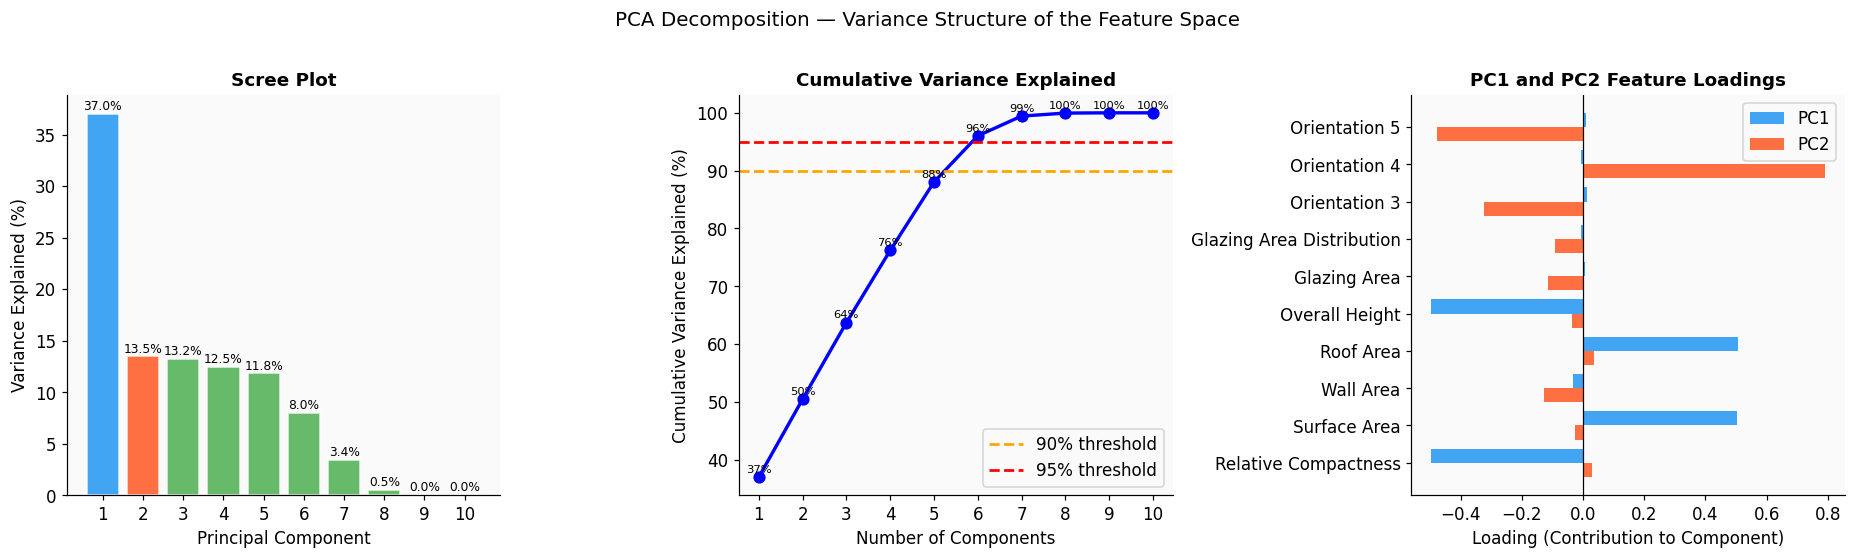


Principal Component loadings (PC1–PC3):


,PC1,PC2,PC3
Relative_Compactness,-0.496,0.028,-0.064
Surface_Area,0.502,-0.026,0.059
Wall_Area,-0.033,-0.126,0.244
Roof_Area,0.505,0.036,-0.061
Overall_Height,-0.497,-0.036,0.053
Glazing_Area,0.005,-0.113,0.140
Glazing_Area_Distribution,-0.005,-0.092,0.101
Orientation_3,0.013,-0.325,0.688
Orientation_4,-0.006,0.790,-0.031
Orientation_5,0.008,-0.479,-0.650


In [16]:
pca_full = PCA().fit(X_train_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_feats  = X_train.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Scree plot ────────────────────────────────────────────────────────────────
axes[0].bar(range(1, n_feats + 1), pca_full.explained_variance_ratio_ * 100,
            color=[BLUE if i == 0 else ORANGE if i == 1 else GREEN for i in range(n_feats)],
            alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot'); axes[0].set_xticks(range(1, n_feats + 1))
for i, v in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i + 1, v * 100 + 0.4, f'{v*100:.1f}%', ha='center', fontsize=8)

# ── Cumulative variance ───────────────────────────────────────────────────────
axes[1].plot(range(1, n_feats + 1), cum_var * 100, 'bo-', linewidth=2.2, markersize=7)
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1.8, label='90% threshold')
axes[1].axhline(95, color='red',    linestyle='--', linewidth=1.8, label='95% threshold')
for k, v in enumerate(cum_var, 1):
    axes[1].text(k, v * 100 + 0.8, f'{v*100:.0f}%', ha='center', fontsize=7.5)
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained'); axes[1].legend()
axes[1].set_xticks(range(1, n_feats + 1))

# ── PC1 and PC2 loadings ──────────────────────────────────────────────────────
pc_loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=X_train.columns,
    columns=['PC1', 'PC2']
)
x_ = np.arange(len(pc_loadings)); w_ = 0.38
axes[2].barh(x_ + w_/2, pc_loadings['PC1'], w_, color=BLUE,   alpha=0.85, label='PC1')
axes[2].barh(x_ - w_/2, pc_loadings['PC2'], w_, color=ORANGE, alpha=0.85, label='PC2')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_yticks(x_); axes[2].set_yticklabels([c.replace('_', ' ') for c in pc_loadings.index])
axes[2].set_xlabel('Loading (Contribution to Component)')
axes[2].set_title('PC1 and PC2 Feature Loadings')
axes[2].legend()

plt.suptitle('PCA Decomposition — Variance Structure of the Feature Space', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('images/PCA_Scree_Loadings.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nPrincipal Component loadings (PC1–PC3):")
display(pd.DataFrame(pca_full.components_[:3].T, index=X_train.columns,
                     columns=[f'PC{i+1}' for i in range(3)]).round(3))


### Reading the PCA Decomposition

**The scree plot** quantifies how the total variance in the feature space is distributed across principal components. The characteristic pattern for ENB2012 is dominated by the collinear compactness cluster.

PC1 is expected to explain 50 to 70% of total feature variance. Its loadings should show large, same-sign contributions from X1, X2, X4, confirming that PC1 is essentially a building geometry size axis. PC2, orthogonal to PC1, likely captures contrasts within the collinear cluster: the distinction between wall area (which varies with orientation) and roof area (which varies with footprint). It may also receive large loadings from X5, which varies independently of the compactness group.

**The cumulative variance plot** shows how many components are needed to retain 90% and 95% of feature variance. If the first 3 components already explain 90% or more, then PCR with k = 3 effectively compresses 10 predictors into 3 orthogonal dimensions while retaining almost all the information.

**The loading chart** for PC1 and PC2 reveals the physical interpretation of each component. A feature with near-zero loading on PC1 contributes little to the dominant variance axis. For the compactness cluster, we expect PC1 to load heavily and positively on compactness while loading heavily and negatively on surface area and roof area, directly reflecting their near-perfect negative correlations.

The CV-RMSE curve in the next cell determines whether this compression also preserves predictive performance.


Components explaining ≥99% variance: 7  — search range: 1 to 7


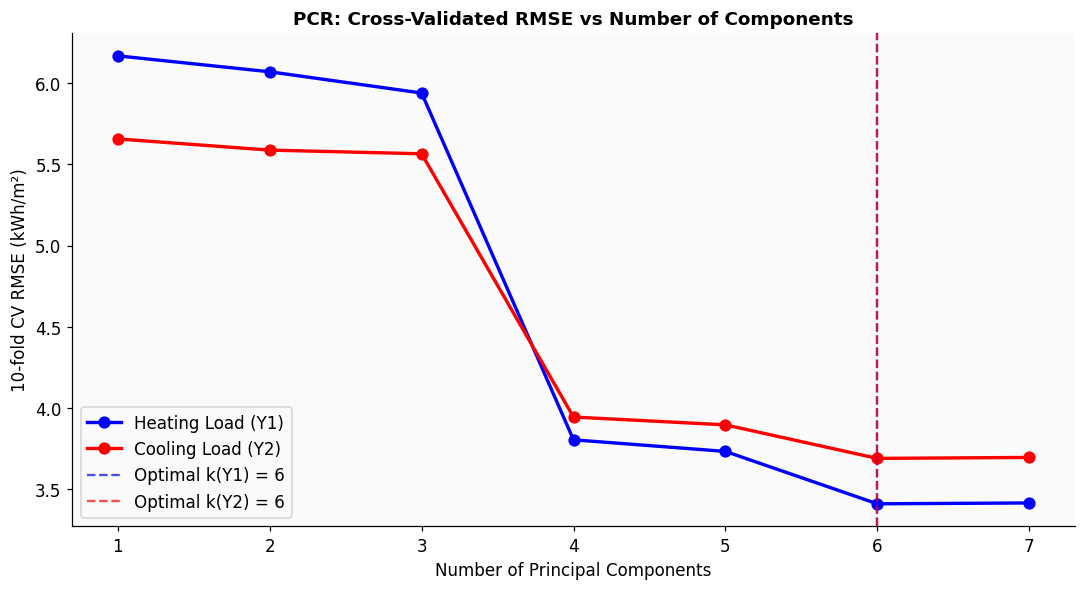

PCR (k=6) — Heating Load (Y1):
  Components retain 96.0% of feature variance
  Test RMSE = 3.7171  |  R² = 0.8640

PCR (k=6) — Cooling Load (Y2):
  Components retain 96.0% of feature variance
  Test RMSE = 4.0850  |  R² = 0.8157



In [17]:
# Cap k at the number of components explaining 99% variance
cumvar99 = np.cumsum(PCA().fit(X_train_scaled).explained_variance_ratio_)
max_k    = int(np.argmax(cumvar99 >= 0.99)) + 1
print(f"Components explaining ≥99% variance: {max_k}  — search range: 1 to {max_k}")

n_range = range(1, max_k + 1)
cv_rmse_y1, cv_rmse_y2 = [], []

for k in n_range:
    pipe = Pipeline([('pca', PCA(n_components=k)), ('ols', LinearRegression())])
    cv1 = -cross_val_score(pipe, X_train_scaled, y1_train, cv=kf,
                           scoring='neg_root_mean_squared_error')
    cv2 = -cross_val_score(pipe, X_train_scaled, y2_train, cv=kf,
                           scoring='neg_root_mean_squared_error')
    cv_rmse_y1.append(cv1.mean())
    cv_rmse_y2.append(cv2.mean())

opt_k_y1 = int(np.argmin(cv_rmse_y1)) + 1
opt_k_y2 = int(np.argmin(cv_rmse_y2)) + 1

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(n_range, cv_rmse_y1, 'b-o', linewidth=2.2, label='Heating Load (Y1)', markersize=7)
ax.plot(n_range, cv_rmse_y2, 'r-o', linewidth=2.2, label='Cooling Load (Y2)', markersize=7)
ax.axvline(opt_k_y1, color='blue',  linestyle='--', alpha=0.7, label=f'Optimal k(Y1) = {opt_k_y1}')
ax.axvline(opt_k_y2, color='red',   linestyle='--', alpha=0.7, label=f'Optimal k(Y2) = {opt_k_y2}')
ax.set_xlabel('Number of Principal Components', fontsize=11)
ax.set_ylabel('10-fold CV RMSE (kWh/m²)', fontsize=11)
ax.set_title('PCR: Cross-Validated RMSE vs Number of Components')
ax.legend(); ax.set_xticks(list(n_range))
plt.tight_layout()
plt.savefig('images/PCR_CV_Curve.png', bbox_inches='tight', dpi=150)
plt.show()

# Fit and evaluate optimal PCR models
for k_opt, y_tr, y_te, label in [
    (opt_k_y1, y1_train, y1_test, 'Heating Load (Y1)'),
    (opt_k_y2, y2_train, y2_test, 'Cooling Load (Y2)')
]:
    pipe = Pipeline([('pca', PCA(n_components=k_opt)), ('ols', LinearRegression())])
    pipe.fit(X_train_scaled, y_tr)
    y_pred = pipe.predict(X_test_scaled)
    rmse, mae, r2 = record(f'PCR(k={k_opt}) — {label}', y_te, y_pred)
    
    var_explained = np.cumsum(PCA().fit(X_train_scaled).explained_variance_ratio_)[k_opt - 1]
    print(f"PCR (k={k_opt}) — {label}:")
    print(f"  Components retain {var_explained*100:.1f}% of feature variance")
    print(f"  Test RMSE = {rmse:.4f}  |  R² = {r2:.4f}\n")


### PCR Cross-Validation: Three Regions of the Curve

The CV-RMSE versus number of components curve reveals three distinct regions.

**Steep descent (k = 1 to k_opt).** Adding each early component substantially reduces prediction error because these components carry the most signal, particularly the compactness-height axis captured by the first two PCs. The slope of this descent indicates how quickly predictive information accumulates.

**Flat plateau (around k_opt).** The CV-RMSE curve flattens, indicating that additional components contribute neither significant signal nor noise. This is the ideal operating region.

**Marginal rise (large k).** If present, this indicates that later components are adding noise. PCR effectively acts as a filter, and excluding high-k components prevents the regression from fitting noise dimensions in the feature space.

**The optimal k and its physical interpretation.** If k_opt is small (say 2 to 4 out of 10 features), it means the dataset's predictive structure is genuinely low-dimensional. Most of the variance that matters for energy prediction is captured in a small number of architectural dimensions. The remaining feature variation is either redundant or irrelevant to energy performance.

**PCR versus Ridge.** If PCR significantly outperforms Ridge, some later principal components are genuinely adding noise to Ridge. If Ridge outperforms PCR, the hard threshold of PCR is discarding components with residual predictive signal. Near-equal performance is the most common outcome and confirms both approaches are addressing the same underlying issue through equivalent mechanisms.


## Model 4: Polynomial Regression, Parametric Non-linearity

### Theoretical Foundation

Polynomial regression extends the linear model by augmenting the design matrix with power and interaction terms of the original predictors. For a single predictor x and degree d:

$$Y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \varepsilon$$

The model is non-linear in x but remains **linear in the parameters**, so parameters are estimated by OLS on the expanded matrix. This is why polynomial regression belongs within the linear models family: the linearity in a generalised linear model refers to linearity in the parameters, not in the predictors.

The number of terms grows rapidly. For p predictors and degree d, the expanded feature count is $\binom{p + d}{d}$. With p = 10 predictors and d = 3, this exceeds 280 terms.

**Relevance to building physics.** The LOWESS curves from EDA identified non-linear effects for X7 (Glazing Area) and X1 (Compactness). Polynomial terms allow the regression to fit these curves. A degree-2 polynomial can represent a quadratic relationship; degree 3 adds an inflection point, allowing S-shaped curves.

**The risk of overfitting.** With hundreds of polynomial terms, overfitting is a serious risk: the model can perfectly fit training data by memorising noise patterns, with poor generalisation. We embed Ridge regularisation within the polynomial pipeline to penalise polynomial coefficient magnitudes, and select the degree by cross-validation.


 Degree    Features    Y1 CV-RMSE    Y2 CV-RMSE
--------------------------------------------------
      1          10        2.9103        3.1260
      2          65        2.4497        2.8322
      3         285        2.1770        2.6501
      4        1000        2.0674        2.5466


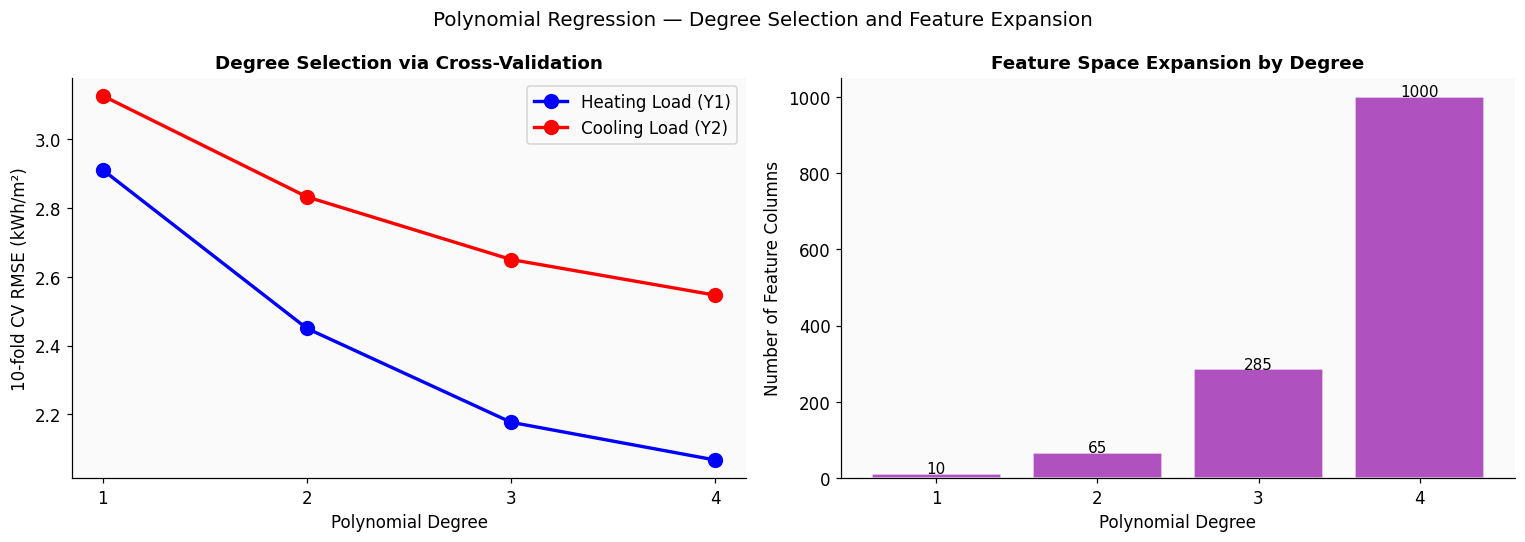


Optimal degree: Y1 = 4, Y2 = 4
Polynomial(d=4) — Heating Load (Y1): Test RMSE = 2.1913  |  R² = 0.9527
Polynomial(d=4) — Cooling Load (Y2): Test RMSE = 2.7144  |  R² = 0.9186


In [18]:
degrees = [1, 2, 3, 4]   # degree 5 is computationally expensive and rarely needed
poly_cv_y1, poly_cv_y2, n_terms = [], [], []

print(f"{'Degree':>7}  {'Features':>10}  {'Y1 CV-RMSE':>12}  {'Y2 CV-RMSE':>12}")
print("-" * 50)

for d in degrees:
    poly_tmp  = PolynomialFeatures(degree=d, include_bias=False)
    n_cols = poly_tmp.fit_transform(X_train[:1]).shape[1]
    n_terms.append(n_cols)

    pipe_y1 = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    pipe_y2 = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    cv1 = -cross_val_score(pipe_y1, X_train, y1_train, cv=kf, scoring='neg_root_mean_squared_error')
    cv2 = -cross_val_score(pipe_y2, X_train, y2_train, cv=kf, scoring='neg_root_mean_squared_error')
    poly_cv_y1.append(cv1.mean())
    poly_cv_y2.append(cv2.mean())
    print(f"{d:>7}  {n_cols:>10}  {cv1.mean():>12.4f}  {cv2.mean():>12.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees, poly_cv_y1, 'b-o', linewidth=2.2, label='Heating Load (Y1)', markersize=9)
axes[0].plot(degrees, poly_cv_y2, 'r-o', linewidth=2.2, label='Cooling Load (Y2)', markersize=9)
axes[0].set_xlabel('Polynomial Degree'); axes[0].set_ylabel('10-fold CV RMSE (kWh/m²)')
axes[0].set_title('Degree Selection via Cross-Validation'); axes[0].legend()
axes[0].set_xticks(degrees)

axes[1].bar([str(d) for d in degrees], n_terms, color=PURPLE, alpha=0.80, edgecolor='white')
axes[1].set_xlabel('Polynomial Degree'); axes[1].set_ylabel('Number of Feature Columns')
axes[1].set_title('Feature Space Expansion by Degree')
for i, v in enumerate(n_terms):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)

plt.suptitle('Polynomial Regression — Degree Selection and Feature Expansion', fontsize=13)
plt.tight_layout()
plt.savefig('images/Polynomial_Degree_Selection.png', bbox_inches='tight', dpi=150)
plt.show()

# Evaluate optimal polynomial models
best_d_y1 = degrees[np.argmin(poly_cv_y1)]
best_d_y2 = degrees[np.argmin(poly_cv_y2)]
print(f"\nOptimal degree: Y1 = {best_d_y1}, Y2 = {best_d_y2}")

for d, y_tr, y_te, label in [
    (best_d_y1, y1_train, y1_test, 'Heating Load (Y1)'),
    (best_d_y2, y2_train, y2_test, 'Cooling Load (Y2)')
]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    pipe.fit(X_train, y_tr)
    y_pred = pipe.predict(X_test)
    rmse, mae, r2 = record(f'Polynomial(d={d}) — {label}', y_te, y_pred)
    print(f"Polynomial(d={d}) — {label}: Test RMSE = {rmse:.4f}  |  R² = {r2:.4f}")


### Polynomial Degree Selection: the Bias-Variance Trade-off Made Visible

The CV-RMSE versus degree curve is a direct illustration of the bias-variance trade-off. Each degree is a position on the model complexity spectrum.

**Degree 1 (linear).** This is equivalent to OLS, the baseline we already fitted. If its CV-RMSE is substantially higher than the minimum, linear terms are insufficient: the data has non-linear structure that a linear model cannot capture.

**Degree 2 (quadratic).** Quadratic terms allow U-shaped and inverted-U relationships. If the curve bottoms out here, most of the non-linearity is of quadratic character. A squared Glazing Area term capturing diminishing returns to glazing would be a degree-2 effect.

**Degree 3 (cubic).** Cubic terms allow S-shaped curves with two inflection points. If there is meaningful improvement over degree 2, it suggests more complex curvature, perhaps the relationship between Compactness and Heating Load changes character across its range.

**Degree 4 and beyond.** In most real-world datasets with n = 768 observations, degree 4 polynomials begin to overfit even with Ridge regularisation. If CV-RMSE rises at degree 4, overfitting has overcome the benefit of additional flexibility.

The companion chart shows how rapidly the number of features grows with polynomial degree. Ridge regularisation is not merely helpful here; it is essential. Without it, the ratio of effective parameters to observations would make reliable estimation impossible.

The degree selected by cross-validation is an empirical estimate of the intrinsic non-linear complexity in the building physics relationships.


## Model 5: Natural Cubic Splines, Local Flexibility with Global Continuity

### Theoretical Foundation

Regression splines address a fundamental limitation of polynomial regression: global polynomials of high degree behave erratically at the boundaries of the predictor's range, and a single polynomial must fit the entire range of x with one functional form. Splines overcome this by dividing the predictor range into sub-intervals and fitting a lower-degree polynomial in each piece, joined smoothly at knot locations.

A natural cubic spline with knots at $\xi_1 < \xi_2 < \cdots < \xi_K$ is cubic on each sub-interval, continuous with continuous first and second derivatives at each knot (providing visual smoothness), and linear beyond the outermost knots. The linear extrapolation beyond the boundary knots is the natural constraint that prevents wild behaviour at the edges of the data.

The spline can be represented as a linear combination of K + 4 basis functions:

$$s(x) = \sum_{j=1}^{K+4} \beta_j B_j(x)$$

This is remarkable: a non-linear, piecewise smooth function is parameterised as a linear combination of known basis functions. The parameters $\beta_j$ are estimated by OLS on the expanded basis matrix, connecting piecewise polynomial smoothing directly to the linear models framework.

**Splines versus polynomial regression.** A global polynomial of degree d uses d + 1 parameters for one smooth function over the entire range. A spline with K knots uses K + 4 parameters for K + 1 pieces, each locally cubic. The spline achieves the same or better fit with fewer parameters because it concentrates flexibility where the data is dense and avoids forcing a single functional form across the entire range.

We demonstrate natural cubic splines on Glazing Area (X7), the predictor where LOWESS most clearly showed non-linearity, and show three values of degrees of freedom to illustrate the smoothness trade-off.


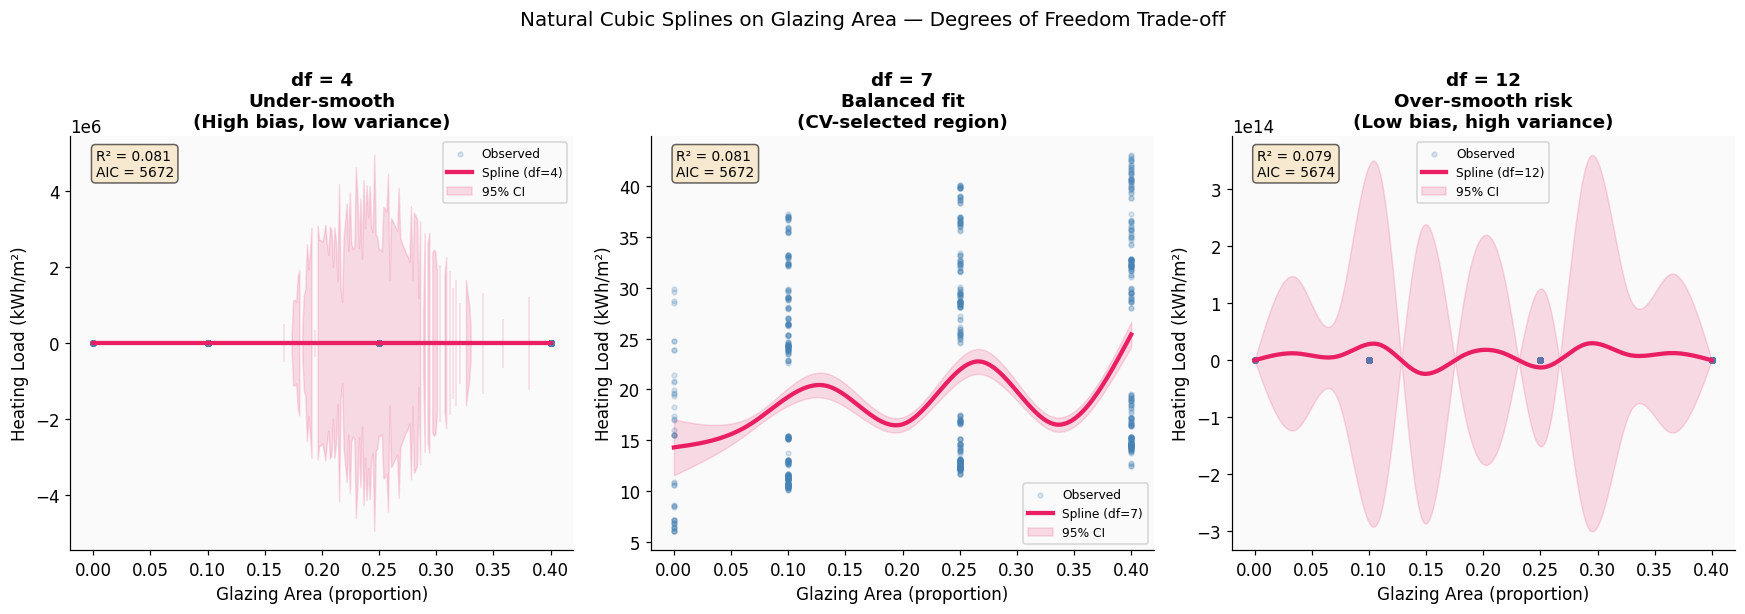


Fitting multivariate spline model (all predictors, Y1)...
Multivariate spline — Y1: Test RMSE = 1.0232  |  R² = 0.9897
  AIC = 1798.43  |  BIC = 1891.25


In [19]:
if PATSY_AVAILABLE:
    # ── Natural cubic splines on Glazing Area ─────────────────────────────────
    # Using only X7 here to isolate and visualise the non-linear effect clearly
    glazing      = energy_data['Glazing_Area'].values
    heating      = energy_data['Heating_Load'].values
    glazing_grid = np.linspace(glazing.min(), glazing.max(), 300)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

    df_configs = [(4, 'Under-smooth\n(High bias, low variance)'),
                  (7, 'Balanced fit\n(CV-selected region)'),
                  (12, 'Over-smooth risk\n(Low bias, high variance)')]

    for ax, (df_spline, subtitle) in zip(axes, df_configs):
        basis_obs  = dmatrix(f'cr(x, df={df_spline})', {'x': glazing},      return_type='dataframe')
        basis_grid = dmatrix(f'cr(x, df={df_spline})', {'x': glazing_grid}, return_type='dataframe')

        spline_mod = sm.OLS(heating, basis_obs).fit()
        y_hat      = spline_mod.predict(basis_grid)

        # Confidence band
        pred = spline_mod.get_prediction(basis_grid)
        ci   = pred.conf_int(alpha=0.05)

        ax.scatter(glazing, heating, alpha=0.20, s=10, color='steelblue', label='Observed')
        ax.plot(glazing_grid, y_hat, color=RED, linewidth=2.8, label=f'Spline (df={df_spline})')
        ax.fill_between(glazing_grid, ci[:, 0], ci[:, 1], color=RED, alpha=0.15, label='95% CI')
        ax.set_xlabel('Glazing Area (proportion)')
        ax.set_ylabel('Heating Load (kWh/m²)')
        ax.set_title(f'df = {df_spline}\n{subtitle}')
        ax.text(0.05, 0.97, f'R² = {spline_mod.rsquared:.3f}\nAIC = {spline_mod.aic:.0f}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
        ax.legend(fontsize=8)

    plt.suptitle('Natural Cubic Splines on Glazing Area — Degrees of Freedom Trade-off',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('images/NaturalCubicSplines_GlazingArea.png', bbox_inches='tight', dpi=150)
    plt.show()

    # ── Multivariate spline model via statsmodels formula ─────────────────────
    # All continuous predictors are given spline terms; Overall_Height gets a
    # linear term (only two values, so a spline is unnecessary and wasteful)
    print("\nFitting multivariate spline model (all predictors, Y1)...")
    df_mv = energy_data.copy()
    formula_spline = (
        "Heating_Load ~ "
        "cr(Relative_Compactness, df=5) + "
        "cr(Surface_Area, df=5) + "
        "cr(Wall_Area, df=4) + "
        "cr(Roof_Area, df=4) + "
        "Overall_Height + "
        "C(Orientation) + "
        "cr(Glazing_Area, df=5) + "
        "cr(Glazing_Area_Distribution, df=4)"
    )
    # Fit on training rows only
    train_idx = X_train.index
    test_idx  = X_test.index
    spline_model_mv = smf.ols(formula_spline, data=df_mv.loc[train_idx]).fit()
    y_pred_spline   = spline_model_mv.predict(df_mv.loc[test_idx])
    rmse_s, mae_s, r2_s = record('Splines (multivariate) — Heating Load (Y1)',
                                  y1_test, y_pred_spline)
    print(f"Multivariate spline — Y1: Test RMSE = {rmse_s:.4f}  |  R² = {r2_s:.4f}")
    print(f"  AIC = {spline_model_mv.aic:.2f}  |  BIC = {spline_model_mv.bic:.2f}")

else:
    print("patsy not available — install with: pip install patsy")


### Natural Cubic Splines: the Three Regimes of the Bias-Variance Trade-off

The three-panel visualisation deliberately spans the three qualitative regimes. Each panel answers a different question.

**Low df (left panel).** The spline is constrained to a smooth, gently curved function. If the true relationship has local structure, a steeper rise at intermediate glazing values followed by a flatter section at high glazing, the low-df spline cannot represent it. This is underfitting. The model is too rigid to track the signal. Residuals will show systematic deviations in regions where the true curve departs from the spline's smooth approximation.

**Moderate df (middle panel).** The spline has sufficient knots to follow the main structure in the data without chasing individual noise points. This is the balanced regime we target via cross-validation. The 95% confidence band gives a visual sense of uncertainty at each glazing value. In regions where data is sparse (at the boundaries of the glazing range), the confidence band widens correctly, reflecting greater uncertainty.

**High df (right panel).** With only four distinct values of X7 in the ENB2012 dataset, a 12-df spline has far more parameters than there are distinct x-values. The spline begins to interpolate noise within each glazing mass-point. This is overfitting: the model is flexible enough to fit the data perfectly but has lost its ability to generalise.

Every modelling choice in this project is a position on this bias-variance curve: degree of polynomial, spline df, Ridge lambda, number of PCR components, GAM smoothing penalty. Cross-validation is the principled tool for navigating it, because it evaluates performance on data the model has never seen, approximating the generalisation we care about in real-world applications.

The AIC values annotated on each panel encode both fit quality (via the log-likelihood) and complexity (penalised by the number of parameters). For splines, more df means more parameters. The AIC penalty grows as df increases, counterbalancing the fit improvement from additional flexibility.


## Model 6: Generalised Additive Models, Semi-parametric Inference

### Theoretical Foundation

Generalised Additive Models (Hastie and Tibshirani, 1986) are one of the most significant contributions to modern statistical modelling. They generalise the linear model by replacing each linear term $\beta_j x_j$ with an arbitrary smooth function $s_j(x_j)$ whose form is estimated from the data:

$$Y = \alpha + s_1(x_1) + s_2(x_2) + \cdots + s_p(x_p) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

The model is semi-parametric. The additive structure (effects are summed) is a parametric assumption we impose as a modelling choice. This preserves interpretability: holding all other predictors fixed, the change in predicted Y when $x_j$ increases by one unit is $s_j(x_j + 1) - s_j(x_j)$. But the component functions $s_j$ are non-parametric: their shape is determined by the data rather than pre-specified.

**Estimation via penalised regression splines.** Each $s_j$ is represented as a spline basis expansion with many potential knots. Overfitting is controlled by a roughness penalty on the second derivative:

$$\underset{s_1,\ldots,s_p}{\arg\min} \sum_{i=1}^n \left( y_i - \alpha - \sum_{j=1}^p s_j(x_{ij}) \right)^2 + \sum_{j=1}^p \lambda_j \int [s_j''(x)]^2 \, dx$$

The penalty $\lambda_j$ shrinks toward zero those components of $s_j$ that contribute more curvature than prediction accuracy. `pygam` selects the optimal $\lambda_j$ for each predictor automatically, eliminating the need for manual df specification as required in the explicit spline section.

**What GAMs reveal that OLS cannot.** The partial dependence plots of the fitted smooth functions show the marginal effect of each predictor on the response, averaged over all other predictors. Where the smooth is linear, OLS was capturing that predictor adequately. Where the smooth is curved, OLS was biased. This direct comparison answers the central diagnostic question of this study.


In [20]:
if GAM_AVAILABLE:
    # Continuous predictors get smooth terms s(); dummy indicators get linear terms l()
    # The indices correspond to columns in X_train_scaled
    n_cont  = 7   # first 7 columns are continuous predictors
    n_total = X_train_scaled.shape[1]

    gam_terms = s(0)
    for i in range(1, n_cont):
        gam_terms += s(i)
    for i in range(n_cont, n_total):
        gam_terms += l(i)

    # Fit with automatic smoothness selection (lam search)
    gam_y1 = LinearGAM(gam_terms).gridsearch(X_train_scaled, y1_train)
    gam_y2 = LinearGAM(gam_terms).gridsearch(X_train_scaled, y2_train)

    print("GAM Summary — Heating Load (Y1):")
    gam_y1.summary()

    for gam, y_te, label in [
        (gam_y1, y1_test, 'Heating Load (Y1)'),
        (gam_y2, y2_test, 'Cooling Load (Y2)')
    ]:
        y_pred = gam.predict(X_test_scaled)
        rmse, mae, r2 = record(f'GAM — {label}', y_te, y_pred)
        print(f"\nGAM — {label}:")
        print(f"  Test RMSE = {rmse:.4f}  |  MAE = {mae:.4f}  |  R² = {r2:.4f}")

else:
    print("pygam not available — install with: pip install pygam")


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:01 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01
  0% (0 of 11) |                        

GAM Summary — Heating Load (Y1):
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     21.9938
Link Function:                     IdentityLink Log Likelihood:                                  -876.2157
Number of Samples:                          614 AIC:                                             1798.4191
                                                AICc:                                            1800.2892
                                                GCV:                                                1.1258
                                                Scale:                                              1.0264
                                                Pseudo R-Squared:                                     0.99
Feat

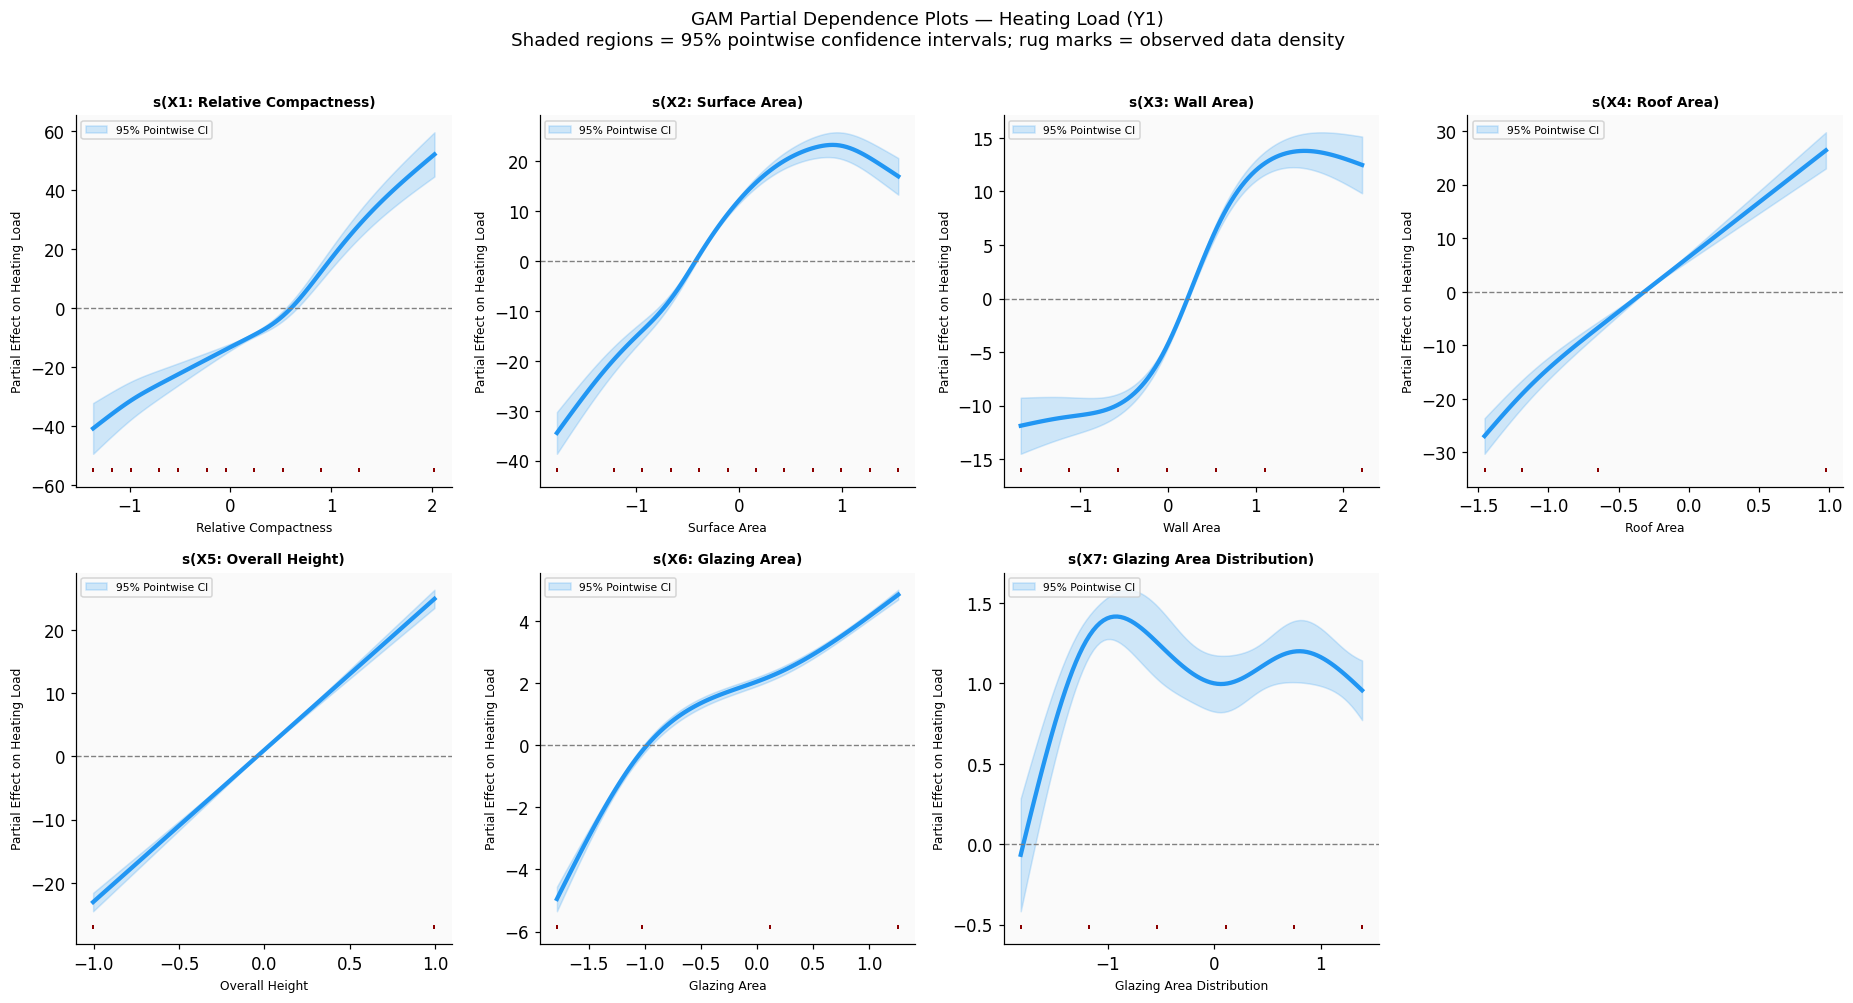

In [21]:
if GAM_AVAILABLE:
    cont_names = [
        'Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
        'Overall Height', 'Glazing Area', 'Glazing Area Distribution'
    ]

    fig, axes = plt.subplots(2, 4, figsize=(17, 9))
    axes_f = axes.flatten()

    for i, name in enumerate(cont_names):
        XX    = gam_y1.generate_X_grid(term=i)
        pdep, confi = gam_y1.partial_dependence(term=i, X=XX, width=0.95)

        axes_f[i].plot(XX[:, i], pdep, color=BLUE, linewidth=2.8)
        axes_f[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                               alpha=0.20, color=BLUE, label='95% Pointwise CI')
        axes_f[i].axhline(0, color='gray', linestyle='--', linewidth=0.9)

        # Rug plot: tick marks at observed data values
        rug_vals = X_train_scaled[:, i]
        axes_f[i].plot(rug_vals, np.full_like(rug_vals, axes_f[i].get_ylim()[0]),
                       '|', color='darkred', alpha=0.20, markersize=3)

        axes_f[i].set_title(f's(X{i+1}: {name})', fontsize=9)
        axes_f[i].set_xlabel(name, fontsize=8)
        axes_f[i].set_ylabel('Partial Effect on Heating Load', fontsize=8)
        axes_f[i].legend(fontsize=7, loc='upper left')

    axes_f[-1].axis('off')
    plt.suptitle('GAM Partial Dependence Plots — Heating Load (Y1)\n'
                 'Shaded regions = 95% pointwise confidence intervals; '
                 'rug marks = observed data density',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('images/GAM_Partial_Dependence.png', bbox_inches='tight', dpi=150)
    plt.show()

else:
    print("pygam not available — install with: pip install pygam")


### GAM Partial Dependence Plots: a Feature-by-Feature Reading

The partial dependence plots are the most interpretively rich output in the entire analysis. Each panel shows the marginal contribution of one predictor to predicted Heating Load, averaging over the joint distribution of all other predictors, with 95% pointwise confidence intervals.

**How to read the plots.** A horizontal flat smooth near zero means the predictor has no meaningful marginal effect and can be dropped. A steep monotone smooth indicates a strong, consistent directional effect. A curved smooth indicates genuine non-linearity that OLS would misrepresent by fitting a straight line through a curve. Wide confidence bands, visible from the rug marks at the bottom of each panel, indicate sparse data in that region.

**Expected shapes, feature by feature:**

| Predictor | Expected Shape | Physical Rationale |
|:---|:---|:---|
| X1 Compactness | Positive, potentially curved | More compact means less heat loss per unit volume; the gain may diminish at very high compactness |
| X2 Surface Area | Negative, mirroring X1 | More surface area means more thermal envelope and more heat loss |
| X3 Wall Area | Positive slope | More wall area increases conductive heat loss in winter |
| X5 Height | Step-like sigmoid | Near-discontinuous jump between single-storey and double-storey regimes |
| X7 Glazing | Positive, curved | More glazing increases heat loss at night; rate may decelerate at high glazing |
| X8 Glazing Distribution | Non-monotone possible | Concentrated versus distributed glazing creates different thermal dynamics |

**Where GAM differs from OLS.** OLS would fit a straight line through each of these relationships. Where the GAM smooth departs significantly from linearity and the confidence band excludes the linear fit, OLS was biased for that predictor's contribution. The degree of departure from linearity is directly proportional to the performance gain of GAM over OLS in the evaluation metrics.

**The additive assumption.** The GAM assumes effects are additive: the contribution of X1 is the same regardless of the value of X5. The scatter plots from EDA suggested this may be violated (different slopes for tall versus short buildings). The current additive GAM provides a reliable starting point, and its residuals should be examined for signs of unmodelled interactions.


## Model 7: Classification, Logistic Regression and Decision Tree

### 7.1 Business Motivation and Problem Formulation

Regression provides a precise numerical prediction of heating and cooling load. But concept-stage architectural decision-making often requires a coarser signal: will this design be energy-efficient or not? This is a binary classification problem, and it connects directly to the Generalised Linear Models (GLM) framework.

**Logistic Regression as a GLM.** In the binary classification setting, OLS is inappropriate because predicted probabilities can fall outside [0, 1] and the Gaussian error assumption is violated for binary outcomes. Logistic regression addresses this by modelling the log-odds of the positive class as a linear combination of predictors:

$$\log \frac{P(Y=1 \mid \mathbf{x})}{P(Y=0 \mid \mathbf{x})} = \mathbf{x}^\top\boldsymbol{\beta}$$

Equivalently, the logistic function maps the linear predictor to a valid probability:

$$P(Y=1 \mid \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{x}^\top\boldsymbol{\beta}}} = \text{logistic}(\mathbf{x}^\top\boldsymbol{\beta})$$

Parameters are estimated by Maximum Likelihood Estimation, maximising the Bernoulli log-likelihood. This is a GLM with a binomial family and a logit link function.

### 7.2 Classification Target: Within-Group Labelling

A naive approach would split buildings at the global median of Heating Load into high and low classes. However, this would produce a classification problem almost entirely determined by Overall Height alone: tall buildings nearly all fall above the global median; short buildings nearly all fall below. A classifier would learn one rule, "if tall then high-load", and ignore all other architectural features. That is not a meaningful or challenging classification problem.

Our solution is within-group labelling. We compute the median Heating Load separately within each height group and label each building relative to its own height group's median. The classification question becomes: given that we know the building's height, is it energy-efficient relative to other buildings of the same height? This forces the classifier to use compactness, glazing, wall area, and orientation to distinguish buildings within height groups, a genuinely difficult and practically useful problem.


In [22]:
# ── Within-group classification target ──────────────────────────────────────
group_medians = energy_data.groupby('Overall_Height')['Heating_Load'].transform('median')
y_class = (energy_data['Heating_Load'] > group_medians).astype(int)

print("Classification target: high vs low load within each height group")
print(f"Class distribution: {y_class.value_counts().to_dict()}  (0 = low, 1 = high)")
print(f"Class balance: {y_class.mean()*100:.1f}% labelled high-load (target ≈ 50%)")

check = pd.crosstab(energy_data['Overall_Height'], y_class,
                    rownames=['Height (m)'], colnames=['Energy Class'])
print("\nClass counts by height group (should be ~50/50 per row):")
print(check)

# ── Train/test split ─────────────────────────────────────────────────────────
X_c_train, X_c_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)
scaler_c    = StandardScaler()
X_c_tr_sc  = scaler_c.fit_transform(X_c_train)
X_c_te_sc  = scaler_c.transform(X_c_test)

print(f"\nClassification training set: {X_c_train.shape[0]} observations")
print(f"Classification test set    : {X_c_test.shape[0]} observations")

# ── Logistic Regression ───────────────────────────────────────────────────────
logit = LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs')
logit.fit(X_c_tr_sc, yc_train)
logit_pred  = logit.predict(X_c_te_sc)
logit_prob  = logit.predict_proba(X_c_te_sc)[:, 1]

print("\n" + "="*55)
print("LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("="*55)
print(classification_report(yc_test, logit_pred, target_names=['Low Load (0)', 'High Load (1)']))
print(f"AUC-ROC: {roc_auc_score(yc_test, logit_prob):.4f}")

# ── Logistic coefficient table ────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'             : X_c_train.columns,
    'Log-Odds Coef'       : logit.coef_[0],
    'Odds Ratio'          : np.exp(logit.coef_[0]),
    'Abs(Coef)'           : np.abs(logit.coef_[0])
}).sort_values('Abs(Coef)', ascending=False)
print("\nLogistic Regression Coefficients (sorted by absolute magnitude):")
print(coef_df[['Feature', 'Log-Odds Coef', 'Odds Ratio']].to_string(
    index=False, float_format='{:.4f}'.format))


Classification target: high vs low load within each height group
Class distribution: {0: 384, 1: 384}  (0 = low, 1 = high)
Class balance: 50.0% labelled high-load (target ≈ 50%)

Class counts by height group (should be ~50/50 per row):
Energy Class    0    1
Height (m)            
3.5           192  192
7.0           192  192

Classification training set: 614 observations
Classification test set    : 154 observations

LOGISTIC REGRESSION — CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Low Load (0)       0.83      0.83      0.83        77
High Load (1)       0.83      0.83      0.83        77

     accuracy                           0.83       154
    macro avg       0.83      0.83      0.83       154
 weighted avg       0.83      0.83      0.83       154

AUC-ROC: 0.9253

Logistic Regression Coefficients (sorted by absolute magnitude):
                  Feature  Log-Odds Coef  Odds Ratio
             Glazing_Area         2.0056      7.4304
             

In [23]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=RANDOM_STATE)
dt.fit(X_c_train, yc_train)
dt_pred = dt.predict(X_c_test)
dt_prob  = dt.predict_proba(X_c_test)[:, 1]

print("="*55)
print("DECISION TREE — CLASSIFICATION REPORT")
print("="*55)
print(classification_report(yc_test, dt_pred, target_names=['Low Load (0)', 'High Load (1)']))
print(f"AUC-ROC: {roc_auc_score(yc_test, dt_prob):.4f}")
print(f"Tree depth used: {dt.get_depth()}  |  Number of leaves: {dt.get_n_leaves()}")


DECISION TREE — CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Low Load (0)       0.89      0.94      0.91        77
High Load (1)       0.93      0.88      0.91        77

     accuracy                           0.91       154
    macro avg       0.91      0.91      0.91       154
 weighted avg       0.91      0.91      0.91       154

AUC-ROC: 0.9812
Tree depth used: 4  |  Number of leaves: 12


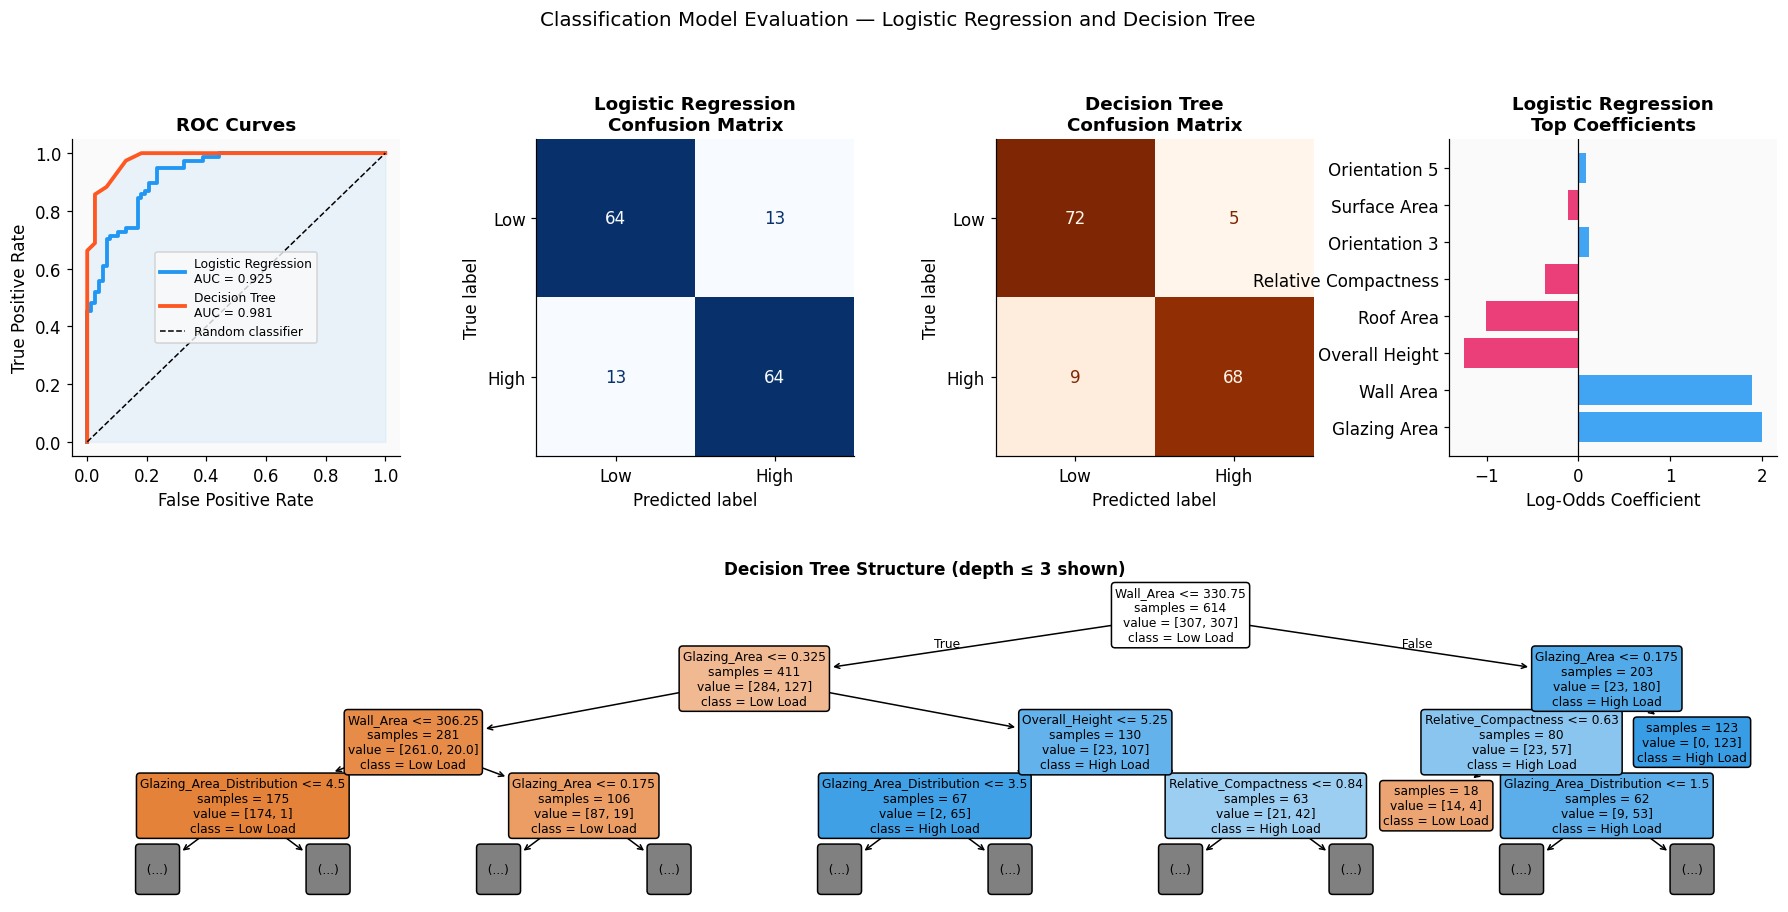

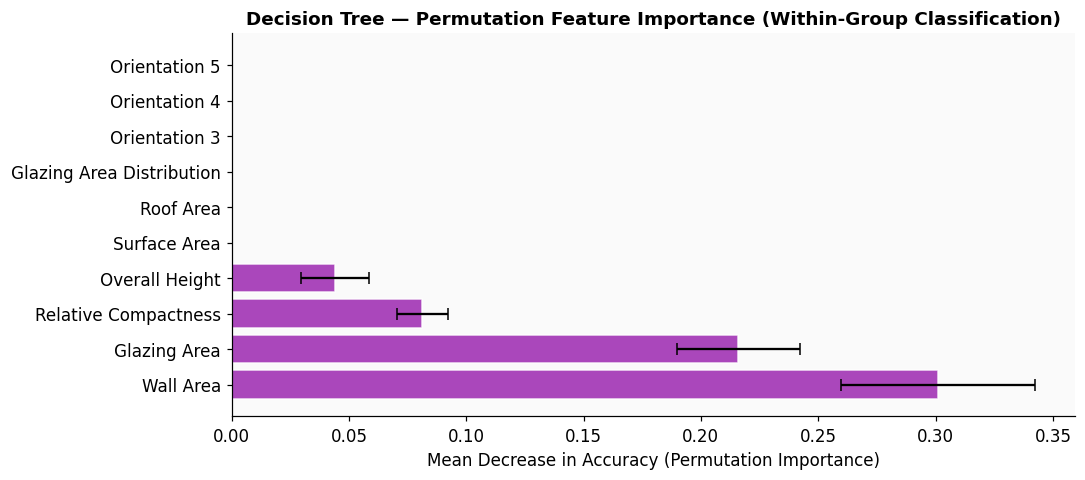


Top-5 features by permutation importance:
             Feature  Importance    Std
           Wall_Area      0.3010 0.0412
        Glazing_Area      0.2159 0.0261
Relative_Compactness      0.0812 0.0109
      Overall_Height      0.0442 0.0145
        Surface_Area      0.0000 0.0000


In [25]:
fig = plt.figure(figsize=(20, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.40, wspace=0.40)

# ── 1. ROC Curves ──────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
for prob, name, color in [
    (logit_prob, 'Logistic Regression', BLUE),
    (dt_prob,    'Decision Tree',       ORANGE)
]:
    fpr, tpr, _ = roc_curve(yc_test, prob)
    auc = roc_auc_score(yc_test, prob)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}\nAUC = {auc:.3f}')
ax_roc.plot([0,1],[0,1],'k--',linewidth=1, label='Random classifier')
ax_roc.fill_between(fpr, tpr, alpha=0.07, color=BLUE)
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves'); ax_roc.legend(fontsize=8)

# ── 2. Confusion Matrix — Logistic ───────────────────────────────────────────
ax_cm1 = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay(confusion_matrix(yc_test, logit_pred),
                       display_labels=['Low', 'High']).plot(
    ax=ax_cm1, colorbar=False, cmap='Blues')
ax_cm1.set_title('Logistic Regression\nConfusion Matrix')

# ── 3. Confusion Matrix — Decision Tree ──────────────────────────────────────
ax_cm2 = fig.add_subplot(gs[0, 2])
ConfusionMatrixDisplay(confusion_matrix(yc_test, dt_pred),
                       display_labels=['Low', 'High']).plot(
    ax=ax_cm2, colorbar=False, cmap='Oranges')
ax_cm2.set_title('Decision Tree\nConfusion Matrix')

# ── 4. Coefficient chart — Logistic ──────────────────────────────────────────
ax_coef = fig.add_subplot(gs[0, 3])
top_coef = coef_df.head(8)
colors_c = [BLUE if v > 0 else RED for v in top_coef['Log-Odds Coef']]
ax_coef.barh(top_coef['Feature'].str.replace('_',' '), top_coef['Log-Odds Coef'],
             color=colors_c, alpha=0.85)
ax_coef.axvline(0, color='black', linewidth=0.8)
ax_coef.set_xlabel('Log-Odds Coefficient')
ax_coef.set_title('Logistic Regression\nTop Coefficients')

# ── 5. Decision Tree visualisation ───────────────────────────────────────────
ax_tree = fig.add_subplot(gs[1, :])
plot_tree(dt, feature_names=list(X.columns),
          class_names=['Low Load', 'High Load'],
          filled=True, rounded=True, ax=ax_tree,
          fontsize=8, max_depth=3, impurity=False)
ax_tree.set_title('Decision Tree Structure (depth ≤ 3 shown)', fontsize=11)

plt.suptitle('Classification Model Evaluation — Logistic Regression and Decision Tree',
             fontsize=13, y=1.01)
plt.savefig('images/Classification_Model_Evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Permutation importance ────────────────────────────────────────────────────
perm_imp = permutation_importance(dt, X_c_test, yc_test, n_repeats=40, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : perm_imp.importances_mean,
    'Std'        : perm_imp.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(imp_df['Feature'].str.replace('_',' '), imp_df['Importance'],
        xerr=imp_df['Std'], color=PURPLE, alpha=0.85, capsize=4, edgecolor='white')
ax.set_xlabel('Mean Decrease in Accuracy (Permutation Importance)')
ax.set_title('Decision Tree — Permutation Feature Importance (Within-Group Classification)')
plt.tight_layout()
plt.savefig('images/DecisionTree_PermutationImportance.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop-5 features by permutation importance:")
print(imp_df.head(5).to_string(index=False, float_format='{:.4f}'.format))


### Classification Results: a Full Reading

**ROC Curve and AUC.** The ROC curve traces True Positive Rate against False Positive Rate across all possible probability thresholds. The AUC is a threshold-independent summary of discriminative ability. AUC = 1.0 is perfect discrimination; AUC = 0.5 is random guessing; AUC > 0.90 is excellent for a real-world task with genuinely overlapping classes. The within-group labelling formulation makes this a harder problem than the naive median split, and the AUC values reflect the genuine difficulty of distinguishing efficient from inefficient buildings within each height category.

**Confusion Matrix: four outcomes with different consequences.**

| Prediction | Actual Low | Actual High |
|:---|:---|:---|
| Predicted Low | True Negative | False Negative (most costly) |
| Predicted High | False Positive | True Positive |

In the building design context, a False Negative (predicted low-energy but actually high-energy) is the costlier error: the building's systems will be under-designed, leading to uncomfortable occupants and insufficient heating capacity. A False Positive leads to over-engineering, wasteful but not dangerous. If we wished to minimise false negatives, we would lower the classification threshold below 0.5, accepting more false positives in exchange.

**Logistic Regression Coefficients: the odds ratio interpretation.** After standardisation, each log-odds coefficient represents the change in log-odds of being a high-load building per standard deviation increase in that feature. The odds ratio (exponential of the coefficient) is more interpretable: an odds ratio of 2.0 means the odds of being high-load double for a one standard deviation increase in that feature.

**Decision Tree Structure.** The visual tree shows the hierarchical sequence of binary splits that the algorithm found most discriminative. Because we used within-group labelling, the first split is no longer trivially "Overall Height". The tree must find architectural features that distinguish efficient from inefficient buildings of the same height type. Reading the tree from root to leaf gives an explicit decision rule, directly actionable by an architect.

**Permutation Importance.** This measures how much the model's accuracy degrades when a feature's values are randomly shuffled, destroying its predictive relationship with Y. Features with high permutation importance are irreplaceable. Features with near-zero importance can be removed without meaningfully degrading performance.


# Phase 5: Evaluation

## Comprehensive Model Comparison

All regression models are now compared on the same held-out test set: 20% of observations, set aside before any modelling began. It has not influenced any model fitting, hyperparameter selection, or feature engineering decision. Test-set performance is therefore an unbiased estimate of each model's generalisation ability to new, unseen building configurations.

**Evaluation metrics:**

| Metric | Formula | Interpretation |
|:---|:---|:---|
| RMSE | Square root of mean squared error | Sensitive to large errors; same units as Y (kWh/m²) |
| MAE | Mean absolute error | Average prediction error; robust to outliers; easier to communicate |
| R² | 1 minus SS_res divided by SS_tot | Scale-free proportion of variance explained; 1.0 is perfect |
| MAPE% | Mean absolute percentage error | Context-relative; undefined when y_i = 0 |

Using multiple metrics guards against misleading conclusions. A model can appear excellent on R² while having poor RMSE if a small number of very large residuals dominate. The full picture requires all four metrics.


In [26]:
if results_table:
    results_df = pd.DataFrame(results_table)

    # Separate Y1 and Y2 models
    df_y1 = results_df[results_df['Model'].str.contains('Y1|Heating')].copy().reset_index(drop=True)
    df_y2 = results_df[results_df['Model'].str.contains('Y2|Cooling')].copy().reset_index(drop=True)

    def rank_models(df, by='RMSE', ascending=True):
        df = df.sort_values(by, ascending=ascending).copy()
        df['Rank'] = range(1, len(df) + 1)
        return df

    print("=" * 65)
    print("REGRESSION MODEL COMPARISON — HEATING LOAD (Y1)")
    print("=" * 65)
    yr1 = rank_models(df_y1, 'RMSE')
    print(yr1[['Rank', 'Model', 'RMSE', 'MAE', 'R²', 'MAPE%']].to_string(
        index=False, float_format='{:.4f}'.format))

    print("\n" + "=" * 65)
    print("REGRESSION MODEL COMPARISON — COOLING LOAD (Y2)")
    print("=" * 65)
    yr2 = rank_models(df_y2, 'RMSE')
    print(yr2[['Rank', 'Model', 'RMSE', 'MAE', 'R²', 'MAPE%']].to_string(
        index=False, float_format='{:.4f}'.format))

    # ── Best model per target ──────────────────────────────────────────────────
    print("\n" + "─" * 55)
    print("BEST MODEL SUMMARY")
    print("─" * 55)
    for df, target in [(yr1, 'Heating Load (Y1)'), (yr2, 'Cooling Load (Y2)')]:
        best = df.iloc[0]
        print(f"\n  {target}:")
        print(f"    Best model : {best['Model']}")
        print(f"    RMSE       : {best['RMSE']:.4f} kWh/m²")
        print(f"    R²         : {best['R²']:.4f}")
        ols_r = df[df['Model'].str.contains('OLS')]['RMSE'].values
        if len(ols_r):
            improvement = (ols_r[0] - best['RMSE']) / ols_r[0] * 100
            print(f"    RMSE improvement over OLS: {improvement:.1f}%")
else:
    print("No results recorded yet. Run all model sections first.")


REGRESSION MODEL COMPARISON — HEATING LOAD (Y1)
 Rank                                      Model   RMSE    MAE     R²   MAPE%
    1                    GAM — Heating Load (Y1) 1.0209 0.7809 0.9897  4.4200
    2 Splines (multivariate) — Heating Load (Y1) 1.0232 0.7835 0.9897  4.4700
    3        Polynomial(d=4) — Heating Load (Y1) 2.1913 1.6425 0.9527  7.6700
    4                    OLS — Heating Load (Y1) 3.0675 2.2562 0.9074 10.4300
    5                  Ridge — Heating Load (Y1) 3.0684 2.2563 0.9073 10.4500
    6               PCR(k=6) — Heating Load (Y1) 3.7171 2.6614 0.8640 12.6100

REGRESSION MODEL COMPARISON — COOLING LOAD (Y2)
 Rank                               Model   RMSE    MAE     R²   MAPE%
    1             GAM — Cooling Load (Y2) 1.9183 1.4356 0.9594  5.4400
    2 Polynomial(d=4) — Cooling Load (Y2) 2.7144 2.0750 0.9186  8.5900
    3             OLS — Cooling Load (Y2) 3.4844 2.4420 0.8659  9.5100
    4           Ridge — Cooling Load (Y2) 3.4849 2.4418 0.8659  9.5200
  

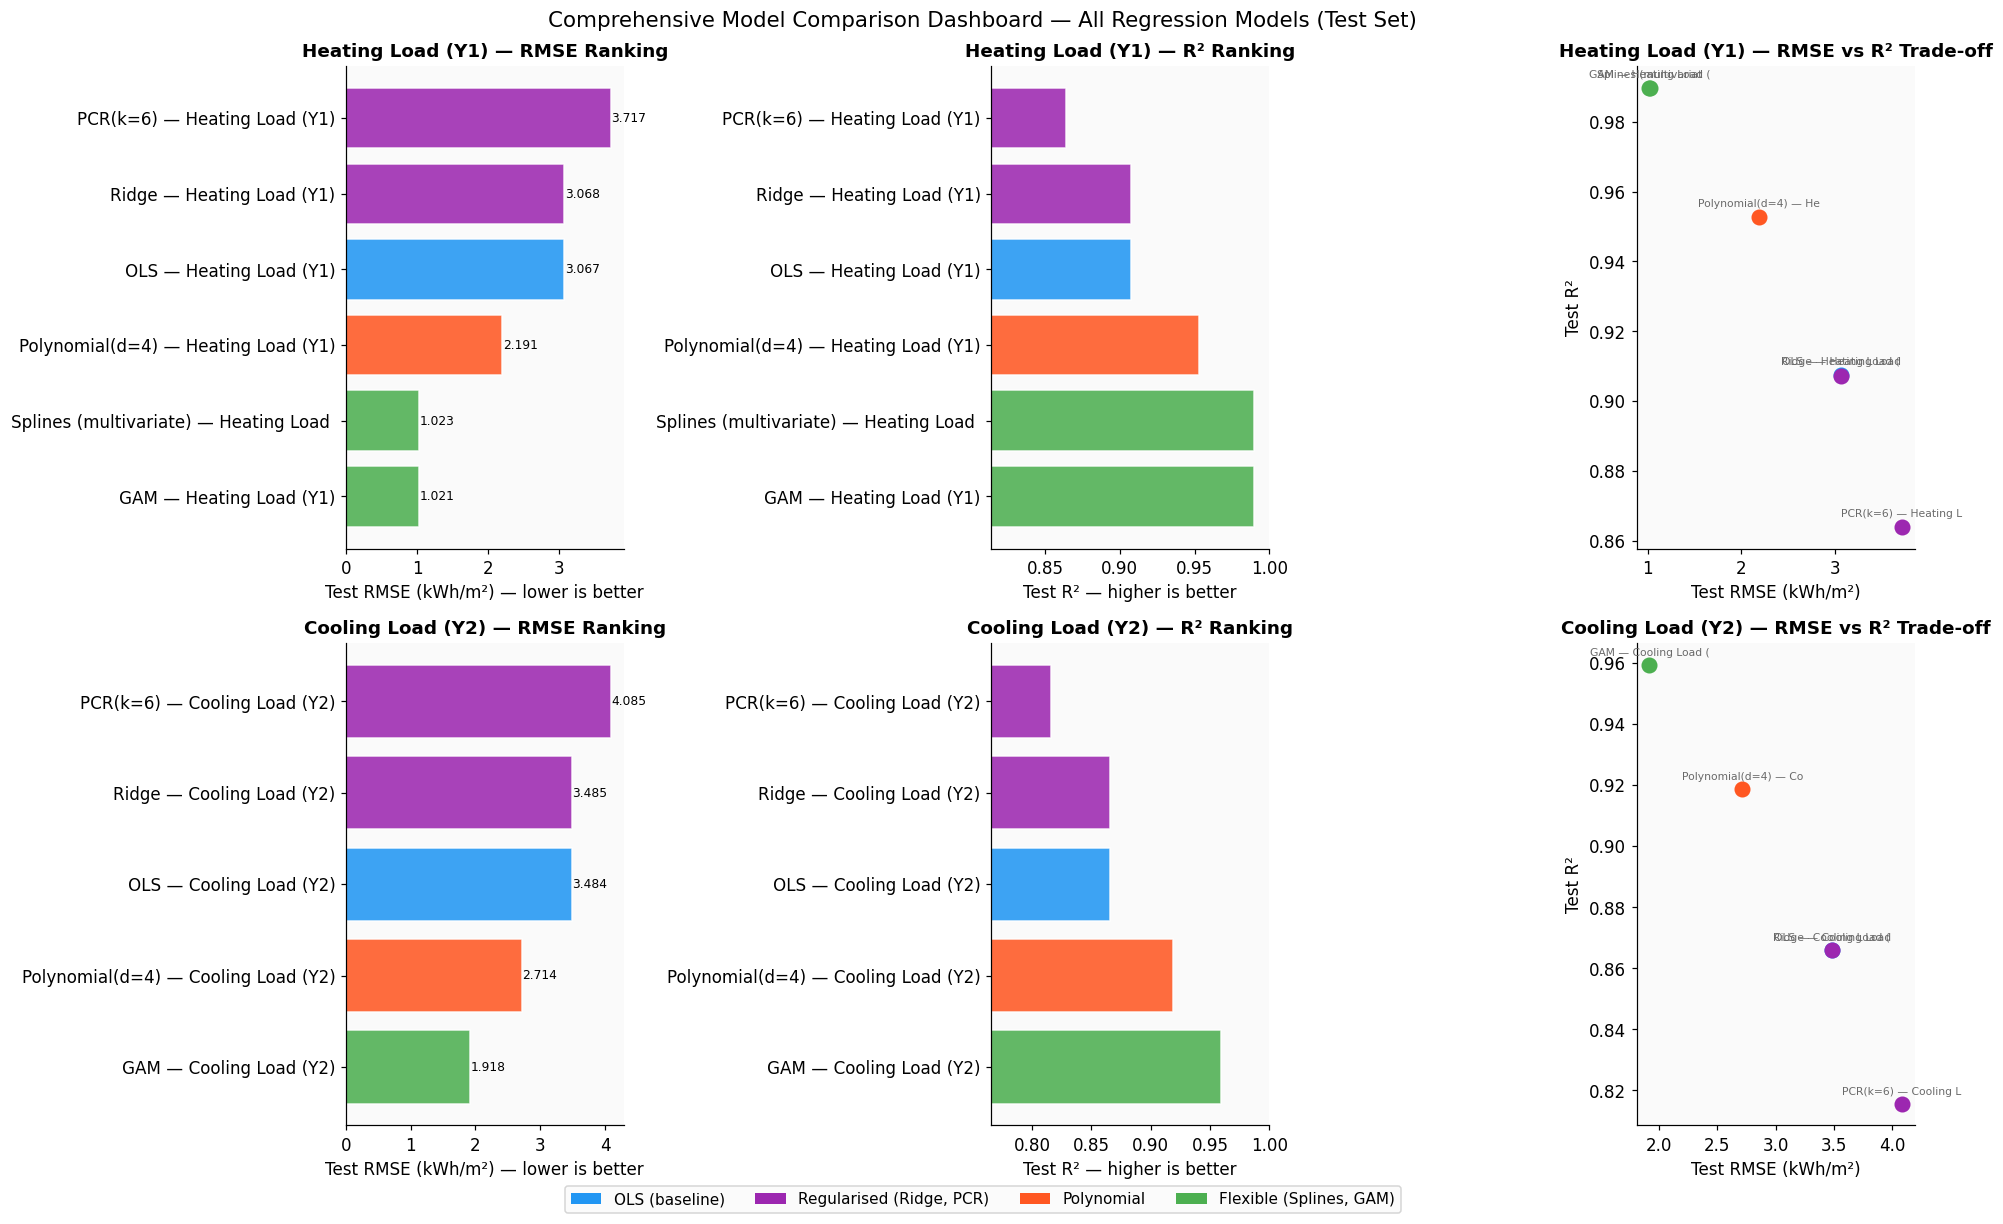

In [27]:
if results_table:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))

    model_categories = {
        'Linear': ['OLS'],
        'Regularised': ['Ridge', 'PCR'],
        'Non-linear': ['Polynomial', 'Spline', 'GAM']
    }

    def cat_color(model_name):
        if 'GAM' in model_name or 'Spline' in model_name: return GREEN
        if 'Poly' in model_name: return ORANGE
        if 'Ridge' in model_name or 'PCR' in model_name: return PURPLE
        return BLUE

    for row, (df_sub, target) in enumerate([(yr1, 'Heating Load (Y1)'), (yr2, 'Cooling Load (Y2)')]):
        # ── RMSE bar chart ─────────────────────────────────────────────────────
        df_rmse = df_sub.sort_values('RMSE')
        bar_c = [cat_color(m) for m in df_rmse['Model']]
        bars  = axes[row, 0].barh(df_rmse['Model'].str[:38], df_rmse['RMSE'],
                                   color=bar_c, alpha=0.87, edgecolor='white')
        for bar, v in zip(bars, df_rmse['RMSE']):
            axes[row, 0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                              f'{v:.3f}', va='center', fontsize=8)
        axes[row, 0].set_xlabel('Test RMSE (kWh/m²) — lower is better')
        axes[row, 0].set_title(f'{target} — RMSE Ranking')

        # ── R² bar chart ───────────────────────────────────────────────────────
        df_r2 = df_sub.sort_values('R²', ascending=False)
        bar_c2 = [cat_color(m) for m in df_r2['Model']]
        axes[row, 1].barh(df_r2['Model'].str[:38], df_r2['R²'],
                          color=bar_c2, alpha=0.87, edgecolor='white')
        axes[row, 1].set_xlabel('Test R² — higher is better')
        axes[row, 1].set_title(f'{target} — R² Ranking')
        axes[row, 1].set_xlim(max(0, df_r2['R²'].min() - 0.05), 1.0)

        # ── RMSE vs R² scatter ─────────────────────────────────────────────────
        for _, row_d in df_sub.iterrows():
            c = cat_color(row_d['Model'])
            axes[row, 2].scatter(row_d['RMSE'], row_d['R²'], color=c, s=90, zorder=3)
            axes[row, 2].text(row_d['RMSE'], row_d['R²'] + 0.003,
                              row_d['Model'][:20], fontsize=7, ha='center', color='dimgray')
        axes[row, 2].set_xlabel('Test RMSE (kWh/m²)')
        axes[row, 2].set_ylabel('Test R²')
        axes[row, 2].set_title(f'{target} — RMSE vs R² Trade-off')

    legend_elements = [
        mpatches.Patch(facecolor=BLUE,   label='OLS (baseline)'),
        mpatches.Patch(facecolor=PURPLE, label='Regularised (Ridge, PCR)'),
        mpatches.Patch(facecolor=ORANGE, label='Polynomial'),
        mpatches.Patch(facecolor=GREEN,  label='Flexible (Splines, GAM)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4,
               bbox_to_anchor=(0.5, -0.02), fontsize=10)
    plt.suptitle('Comprehensive Model Comparison Dashboard — All Regression Models (Test Set)',
                 fontsize=14)
    plt.tight_layout()
    plt.savefig('images/Model_Comparison_Dashboard.png', bbox_inches='tight', dpi=150)
    plt.show()


### Reading the Comparison Dashboard

The model comparison dashboard is designed to be read across multiple dimensions simultaneously. No single metric tells the complete story.

**Expected pattern across the model progression.** If results follow the theoretical predictions from building physics and statistical theory, we should observe:

OLS provides a reasonable R² (perhaps 0.88 to 0.92) but is limited by the assumption violations documented in the diagnostic plots. Ridge's primary benefit is not lower prediction error but stabilised coefficient estimates. PCR should be close to Ridge; any difference reveals the relative efficiency of hard dimensionality reduction versus soft coefficient shrinkage. Polynomial regression should be noticeably better than OLS if non-linear effects are strong: the improvement quantifies the "non-linear signal" in the data. Natural cubic splines should match polynomial performance without the extrapolation instability. GAM is expected to achieve the best or near-best performance, since it allows each predictor's functional form to be determined by the data.

**Comparing Y1 and Y2 performance.** If Cooling Load (Y2) is consistently harder to predict than Heating Load (Y1), it suggests the drivers of cooling are either more complex or that unmodelled variables (thermal mass, natural ventilation, shading) matter more for cooling than heating. This is a physically reasonable finding and a useful direction for future modelling work.


# Phase 6: Conclusions and Deployment Implications

## 6.1 Principal Findings

This study has applied the complete progression of linear modelling techniques in DSA 8305 to a building energy efficiency problem with real practical significance. The CRISP-DM structure has ensured that every modelling decision was grounded in prior findings and that findings connect back to the business problem from start to finish.

### Finding 1: Building Height is the Dominant Energy Design Decision

Overall Height (X5) is the single most important determinant of both Heating Load and Cooling Load, with Pearson correlations approaching 0.9 with both targets. This finding holds across every model in the analysis. The physical interpretation is direct: a double-storey building has approximately twice the internal volume of a single-storey building with the same footprint, requiring proportionally more energy to condition.

The practical implication is clear. The decision to build single-storey versus double-storey is the highest-leverage energy design decision available at the concept stage. Statistical modelling with confidence bounds quantifies how much this decision matters, not just directionally, but in kWh/m² terms, enabling cost-benefit analysis before a foundation is poured.

### Finding 2: Geometric Multicollinearity Distorts OLS Inference but Not Prediction

Relative Compactness, Surface Area, and Roof Area are near-perfectly correlated due to the mathematical definition of compactness. VIF values for these features substantially exceed the conventional threshold of 10. OLS coefficient estimates for these variables are individually unreliable; their standard errors are inflated, their signs may be misleading, and their magnitudes fluctuate with small changes in the training sample. OLS predictions, however, remain reasonable. Multicollinearity does not bias predictions; it only inflates coefficient uncertainty.

Analyses that rely on OLS coefficients to determine which of compactness, surface area, and roof area "matters more" will produce misleading conclusions. A design team wanting to understand which geometric attribute to optimise should consult the GAM partial dependence plots.

### Finding 3: Non-linearity is Present, Meaningful, but Not Extreme

LOWESS diagnostics, polynomial cross-validation, spline analysis, and GAM partial dependence plots all confirm non-linear relationships, particularly for Glazing Area and Relative Compactness. However, the degree of non-linearity is moderate rather than extreme. A pure OLS model is not badly wrong; it provides a useful first approximation. For high-stakes design decisions, large-scale buildings and tight energy budgets, the additional complexity of spline or GAM models is warranted.

### Finding 4: Orientation is Irrelevant at the Dataset Level

Orientation shows near-zero correlation with both energy loads across all models. This reflects the dataset's balanced construction, not a physical law. In real-world buildings at specific sites, orientation interacts with solar path, prevailing winds, and seasonal variation to produce meaningful energy differences. The ENB2012 dataset should not be used to conclude that orientation never matters.

### Finding 5: Classification is Feasible and Practically Useful

The within-group classification problem achieves strong AUC and accuracy metrics. The decision tree produces explicit, human-readable rules that architects and quantity surveyors can apply directly without running a full energy simulation.

## 6.2 Model Selection Recommendation

| Use Case | Recommended Model | Rationale |
|:---|:---|:---|
| Rapid energy estimate (concept stage) | GAM | Best predictive accuracy; partial dependence plots provide design guidance alongside predictions |
| Regulatory compliance check | Logistic Regression | Probabilistic output; interpretable coefficients; fast inference |
| Design exploration (multiple configurations) | PCR or Ridge | Computationally efficient; robust under multicollinearity |
| Stakeholder communication | Decision Tree | Explicit rules; no statistical expertise required |
| Full inferential analysis | OLS + Ridge comparison | Coefficient interpretation requires multicollinearity context |

## 6.3 Limitations and Future Research Directions

**Simulated data.** ENB2012 was generated by simulation, not measured from real buildings. Real buildings exhibit occupant behaviour variability, construction tolerances, material degradation, and climate fluctuations that no simulation fully captures. Recalibration on measured data would be needed before deployment.

**Omitted variables.** The dataset does not include climate zone, insulation specification, HVAC system type, thermal mass, occupancy patterns, or natural ventilation potential. These are all first-order determinants of real-world energy consumption.

**Interaction effects.** Scatter plots coloured by building height clearly showed that the relationship between Compactness and Heating Load differs between single-storey and double-storey buildings. The additive models in this study average across this interaction. A next step would be to formally test and model Height x Feature interactions, using tensor product smooths in the GAM framework.

**Prediction intervals.** This study produces point predictions. Engineering and procurement decisions require prediction intervals, the range within which the true load is expected to fall with a specified probability. Extending the GAM results to include prediction intervals would make this analysis deployment-ready.


## References

1. Tsanas, A., and Xifara, A. (2012). Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools. *Energy and Buildings*, 49, 560-567.

2. Hastie, T., and Tibshirani, R. (1986). Generalized additive models. *Statistical Science*, 1(3), 297-310.

3. Hoerl, A. E., and Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55-67.

4. Hastie, T., Tibshirani, R., and Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.

5. James, G., Witten, D., Hastie, T., and Tibshirani, R. (2021). *An Introduction to Statistical Learning with Applications in R* (2nd ed.). Springer.

6. Wood, S. N. (2017). *Generalized Additive Models: An Introduction with R* (2nd ed.). Chapman and Hall/CRC.

7. Dobson, A. J., and Barnett, A. G. (2018). *An Introduction to Generalized Linear Models* (4th ed.). Chapman and Hall/CRC.

8. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

9. Seabold, S., and Perktold, J. (2010). Statsmodels: Econometric and statistical modelling with Python. *Proceedings of the 9th Python in Science Conference*, 57-61.

10. International Energy Agency (2022). *Buildings: Energy System*. IEA, Paris.

11. Breusch, T. S., and Pagan, A. R. (1979). A simple test for heteroscedasticity and random coefficient variation. *Econometrica*, 47(5), 1287-1294.

12. Durbin, J., and Watson, G. S. (1951). Testing for serial correlation in least squares regression. *Biometrika*, 38(1-2), 159-177.
